## LSE Business Analytics for Executives
# Course 3:  Advanced Analytics for Organisational Impact

###  R Analysis: Loyalty Points EDA and Multiple Linear Regression

**Student:** Sadia Saad Yusuf  
**Dataset:** `turtle_reviews.csv`  
**Tools:** R (IRkernel in Jupyter)

---

## Assignment Context

Turtle Games wants to understand how customers accumulate loyalty points and whether a predictive model can be built from existing customer features (age, remuneration, spending score).

**Assignment 5** covers exploratory data analysis using R — cleaning, wrangling, and visualising the data.  
**Assignment 6** covers statistical analysis and building a multiple linear regression model to predict loyalty points.

---

## Assignment 5: Load, Clean, and Wrangle Data Using R

**Objective:** Load and explore the dataset, produce summary statistics and groupings, create scatterplots, histograms, and boxplots, and comment on patterns, outliers, and distributions relevant to the loyalty programme.

---

### 1. Set Up the R Environment

In [2]:
# Install and load required libraries
# Run install.packages() lines once; comment out after first use


install.packages('moments')
install.packages('ggcorrplot')
install.packages('patchwork')

library(tidyverse)
library(moments)
library(ggcorrplot)
library(patchwork)
library(dplyr)

Installing package into 'C:/Users/sadia/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'moments' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\sadia\AppData\Local\Temp\Rtmpon3xr0\downloaded_packages


Installing package into 'C:/Users/sadia/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'ggcorrplot' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\sadia\AppData\Local\Temp\Rtmpon3xr0\downloaded_packages


Installing package into 'C:/Users/sadia/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'patchwork' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\sadia\AppData\Local\Temp\Rtmpon3xr0\downloaded_packages


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### 2. Import and View the Data

In [4]:
# Import the dataset
reviews <- read.csv('turtle_reviews.csv', header = TRUE)

# View the first few rows
head(reviews)

,gender,age,remuneration..k..,spending_score..1.100.,loyalty_points,education,language,platform,product,review,summary
,<chr>,<int>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on the screen itself is at an absolute premium. The fact that 50% of this space is wasted on art (and not terribly informative or needed art as well) makes it completely useless. The only reason that I gave it 2 stars and not 1 was that, technically speaking, it can at least still stand up to block your notes and dice rolls. Other than that, it drops the ball completely.",The fact that 50% of this space is wasted on art (and not terribly informative or needed art ...
2,Male,23,12.30,81,524,graduate,EN,Web,466,"An Open Letter to GaleForce9*: Your unpainted miniatures are very not bad. Your spell cards are great. Your board games are ""meh"". Your DM screens, however, are freaking terrible. I'm still waiting for a single screen that isn't polluted with pointless artwork where useful, reference-able tables should be. Once again, you've created a single use screen that is only useful when running the ""Storm King's Thunder"" adventure. Even despite the fact that it's geared to that adventure path, it's usefulness negligible, at best. I massive swath of the inner panel is wasted on artwork and a bloated overland map, which could have been easily reduced to a single panel in size. And the few table you have are nigh-useless themselves. In short, stop making crap DM screens.",Another worthless Dungeon Master's screen from GaleForce9
3,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are filled with a general Forgotten Realms map is beyond me. Most of one of them is all blue ocean. Such a waste. I don't understand why they can't make these DM Screens more useful for these ""kinds of adventures"" rather than solely the specific adventure. You're supposed to be able to transpose this adventure to other lands outside the Forgotten Realms. So even just a list of new monsters or NPCs would at least be useful than the map. Even more would just be stuff related to running the game but broad-use stuff related to giants. Same thing with Curse of Strahd. Why not make it useful for raven loft, undead or horror campaigns in general... instead a huge amount of screen space is solely mapping out Castle Ravenloft, which is only useful during a small fraction of the time even for the Curse of Strahd adventure, let alone various other Ravenloft adventuring. They really kill the extended use of these screens by not thinking about their potential use, both for the adventure in question, as well as use in a broader sense. The Rage of Demons screen is far more useful for broad under dark adventuring - covering a lot of rules for the various conditions you may suffer... and the map is only one panel. This Storm Giants one is decent for a few tables it includes - but really misses the mark. Maybe they should ask a few DMs what they would use?","pretty, but also pretty useless"
4,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new dm and it's perfect!,Five Stars
5,Female,33,13.94,40,366,graduate,EN,Web,291,"As my review of GF9's previous screens these were completely unnecessary and nearly useless. Skip them, this is the definition of a waste of money.",Money trap
6,Female,24,13.94,76,573,PhD,EN,Web,977,Grandson loves,Five Stars


In [10]:
# View as tibble for cleaner output
as_tibble(reviews)

gender,age,remuneration..k..,spending_score..1.100.,loyalty_points,education,language,platform,product,review,summary
<chr>,<int>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on the screen itself is at an absolute premium. The fact that 50% of this space is wasted on art (and not terribly informative or needed art as well) makes it completely useless. The only reason that I gave it 2 stars and not 1 was that, technically speaking, it can at least still stand up to block your notes and dice rolls. Other than that, it drops the ball completely.",The fact that 50% of this space is wasted on art (and not terribly informative or needed art ...
Male,23,12.30,81,524,graduate,EN,Web,466,"An Open Letter to GaleForce9*: Your unpainted miniatures are very not bad. Your spell cards are great. Your board games are ""meh"". Your DM screens, however, are freaking terrible. I'm still waiting for a single screen that isn't polluted with pointless artwork where useful, reference-able tables should be. Once again, you've created a single use screen that is only useful when running the ""Storm King's Thunder"" adventure. Even despite the fact that it's geared to that adventure path, it's usefulness negligible, at best. I massive swath of the inner panel is wasted on artwork and a bloated overland map, which could have been easily reduced to a single panel in size. And the few table you have are nigh-useless themselves. In short, stop making crap DM screens.",Another worthless Dungeon Master's screen from GaleForce9
Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are filled with a general Forgotten Realms map is beyond me. Most of one of them is all blue ocean. Such a waste. I don't understand why they can't make these DM Screens more useful for these ""kinds of adventures"" rather than solely the specific adventure. You're supposed to be able to transpose this adventure to other lands outside the Forgotten Realms. So even just a list of new monsters or NPCs would at least be useful than the map. Even more would just be stuff related to running the game but broad-use stuff related to giants. Same thing with Curse of Strahd. Why not make it useful for raven loft, undead or horror campaigns in general... instead a huge amount of screen space is solely mapping out Castle Ravenloft, which is only useful during a small fraction of the time even for the Curse of Strahd adventure, let alone various other Ravenloft adventuring. They really kill the extended use of these screens by not thinking about their potential use, both for the adventure in question, as well as use in a broader sense. The Rage of Demons screen is far more useful for broad under dark adventuring - covering a lot of rules for the various conditions you may suffer... and the map is only one panel. This Storm Giants one is decent for a few tables it includes - but really misses the mark. Maybe they should ask a few DMs what they would use?","pretty, but also pretty useless"
Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new dm and it's perfect!,Five Stars
Female,33,13.94,40,366,graduate,EN,Web,291,"As my review of GF9's previous screens these were completely unnecessary and nearly useless. Skip them, this is the definition of a waste of money.",Money trap
Female,24,13.94,76,573,PhD,EN,Web,977,Grandson loves,Five Stars
Female,37,14.76,6,61,diploma,EN,Web,979,"I have bought many gm screens over the years, but this one is the best I have ever seen. It has all the relevant information I need , and no crap filler on it. Very happy with this screen.",Best gm screen ever
Female,25,14.76,94,772,graduate,EN,Web,1012,Came in perfect condition.,Five Stars
Male,66,15.58,3,31,PhD,EN,Web,1031,Could be better but its still great. I love the things on the DM's side of the screen and I actually like the map in the middle makes it easy to refer

In [11]:
# Inspect variable types
glimpse(reviews)

Rows: 2,000
Columns: 11
$ gender                 <chr> "Male", "Male", "Female", "Female", "Female", "…
$ age                    <int> 18, 23, 22, 25, 33, 24, 37, 25, 66, 32, 69, 37,…
$ remuneration..k..      <dbl> 12.30, 12.30, 13.12, 13.12, 13.94, 13.94, 14.76…
$ spending_score..1.100. <int> 39, 81, 6, 77, 40, 76, 6, 94, 3, 72, 14, 99, 15…
$ loyalty_points         <int> 210, 524, 40, 562, 366, 573, 61, 772, 31, 724, …
$ education              <chr> "graduate", "graduate", "graduate", "graduate",…
$ language               <chr> "EN", "EN", "EN", "EN", "EN", "EN", "EN", "EN",…
$ platform               <chr> "Web", "Web", "Web", "Web", "Web", "Web", "Web"…
$ product                <int> 453, 466, 254, 263, 291, 977, 979, 1012, 1031, …
$ review                 <chr> "When it comes to a DM's screen, the space on t…
$ summary                <chr> "The fact that 50% of this space is wasted on a…


### 3. Data Cleaning: Drop and Rename Columns

In [5]:
# Drop 'language' and 'platform' columns (as per module 1 instructions)
reviews2 <- select(reviews, -language, -platform)

# Confirm the remaining columns
colnames(reviews2)

[1] "gender"                 "age"                    "remuneration..k.."     
[4] "spending_score..1.100." "loyalty_points"         "education"             
[7] "product"                "review"                 "summary"

In [6]:
# Rename columns for clarity
reviews2 <- reviews2 %>%
  rename(
    remuneration_k = `remuneration..k..`,
    spending_score  = `spending_score..1.100.`
  )

# Verify renamed columns
colnames(reviews2)

[1] "gender"         "age"            "remuneration_k" "spending_score"
[5] "loyalty_points" "education"      "product"        "review"        
[9] "summary"

In [9]:
# Summary statistics of the cleaned data frame
summary(reviews2)

       gender          age        remuneration_k   spending_score
 Length   :2000   Min.   :17.00   Min.   : 12.30   Min.   : 1    
 N.unique :   2   1st Qu.:29.00   1st Qu.: 30.34   1st Qu.:32    
 N.blank  :   0   Median :38.00   Median : 47.15   Median :50    
 Min.nchar:   4   Mean   :39.49   Mean   : 48.08   Mean   :50    
 Max.nchar:   6   3rd Qu.:49.00   3rd Qu.: 63.96   3rd Qu.:73    
                  Max.   :72.00   Max.   :112.34   Max.   :99    
 loyalty_points     education       product            review    
 Min.   :  25   Length   :2000   Min.   :  107   Length   :2000  
 1st Qu.: 772   N.unique :   5   1st Qu.: 1589   N.unique :1980  
 Median :1276   N.blank  :   0   Median : 3624   N.blank  :   0  
 Mean   :1578   Min.nchar:   3   Mean   : 4321   Min.nchar:   2  
 3rd Qu.:1751   Max.nchar:  12   3rd Qu.: 6654   Max.nchar:8042  
 Max.   :6847                    Max.   :11086                   
      summary    
 Length   :2000  
 N.unique :1432  
 N.blank  :   0  
 Min

In [10]:
# Check for missing values.
colSums(is.na(reviews2))

gender            age remuneration_k spending_score loyalty_points 
             0              0              0              0              0 
     education        product         review        summary 
             0              0              0              0

**Observations:**
- The dataset has 2,000 rows and 9 columns after dropping `language` and `platform`.
- No missing values are present in any column.
- `loyalty_points` ranges widely from 25 to 6,847 with a mean of ~1,578, suggesting significant variation in customer engagement.
- `remuneration_k` ranges from £12.3k to £112.3k — a broad income spread.
- `spending_score` is uniformly distributed between 1 and 99 (mean = 50).

---

### 4. Exploratory Data Analysis — Groupings and Descriptive Statistics

In [11]:
# Summary of loyalty points by education level
loyalty_by_education <- reviews2 %>%
  group_by(education) %>%
  summarise(
    count          = n(),
    mean_loyalty   = round(mean(loyalty_points), 1),
    median_loyalty = median(loyalty_points),
    sd_loyalty     = round(sd(loyalty_points), 1),
    min_loyalty    = min(loyalty_points),
    max_loyalty    = max(loyalty_points)
  ) %>%
  arrange(desc(mean_loyalty))

loyalty_by_education

education,count,mean_loyalty,median_loyalty,sd_loyalty,min_loyalty,max_loyalty
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>
Basic,50,2265.0,1622,1510.3,66,4837
graduate,900,1666.1,1285,1341.1,25,6208
PhD,460,1499.8,1232,1274.5,30,6020
postgraduate,400,1499.1,1281,1136.2,35,6232
diploma,190,1336.0,1239,1162.8,51,6847


In [12]:
# Summary of loyalty points by gender
loyalty_by_gender <- reviews2 %>%
  group_by(gender) %>%
  summarise(
    count          = n(),
    mean_loyalty   = round(mean(loyalty_points), 1),
    median_loyalty = median(loyalty_points),
    sd_loyalty     = round(sd(loyalty_points), 1)
  )

loyalty_by_gender

gender,count,mean_loyalty,median_loyalty,sd_loyalty
<chr>,<int>,<dbl>,<dbl>,<dbl>
Female,1120,1601.2,1281,1251.2
Male,880,1548.6,1248,1323.0


In [18]:
# Joint grouping: education and gender
loyalty_edu_gender <- reviews2 %>%
  group_by(education, gender) %>%
  summarise(
    count        = n(),
    mean_loyalty = round(mean(loyalty_points), 1),
    .groups      = 'drop'
  ) %>%
  arrange(desc(mean_loyalty))

loyalty_edu_gender

education,gender,count,mean_loyalty
<chr>,<chr>,<int>,<dbl>
Basic,Female,20,2283.3
Basic,Male,30,2252.9
graduate,Male,370,1711.3
graduate,Female,530,1634.4
PhD,Female,220,1609.2
postgraduate,Female,240,1596.3
PhD,Male,240,1399.4
diploma,Male,80,1370.1
postgraduate,Male,160,1353.2


In [13]:
# Age banding to explore loyalty by life stage
reviews2 <- reviews2 %>%
  mutate(age_band = case_when(
    age < 25             ~ 'Under 25',
    age >= 25 & age < 35 ~ '25-34',
    age >= 35 & age < 45 ~ '35-44',
    age >= 45 & age < 55 ~ '45-54',
    age >= 55            ~ '55+'
  ))

# Loyalty points by age band
loyalty_by_age <- reviews2 %>%
  group_by(age_band) %>%
  summarise(
    count          = n(),
    mean_loyalty   = round(mean(loyalty_points), 1),
    median_loyalty = median(loyalty_points)
  ) %>%
  arrange(mean_loyalty)

loyalty_by_age

age_band,count,mean_loyalty,median_loyalty
<chr>,<int>,<dbl>,<dbl>
Under 25,250,877.5,944
55+,290,1187.7,1268
45-54,340,1407.4,1344
35-44,560,1781.5,1389
25-34,560,1993.0,1346


**Observations from Groupings:**
- Customers with only a Basic education level have the highest average loyalty points (~2,265), which is counterintuitive and warrants further investigation — this small group (n=50) may be an anomaly or may reflect a distinct customer profile.
- Graduates form the largest group (n=900) with a mean of ~1,666 loyalty points.
- PhD and postgraduate customers have nearly identical mean loyalty (~1,499–1,500).
- Gender differences in loyalty are minimal: females average ~1,601 vs males ~1,549.

---

### 5. Visualisations — Scatterplots, Histograms, and Boxplots

#### 5a) Scatterplots

`geom_smooth()` using formula = 'y ~ x'


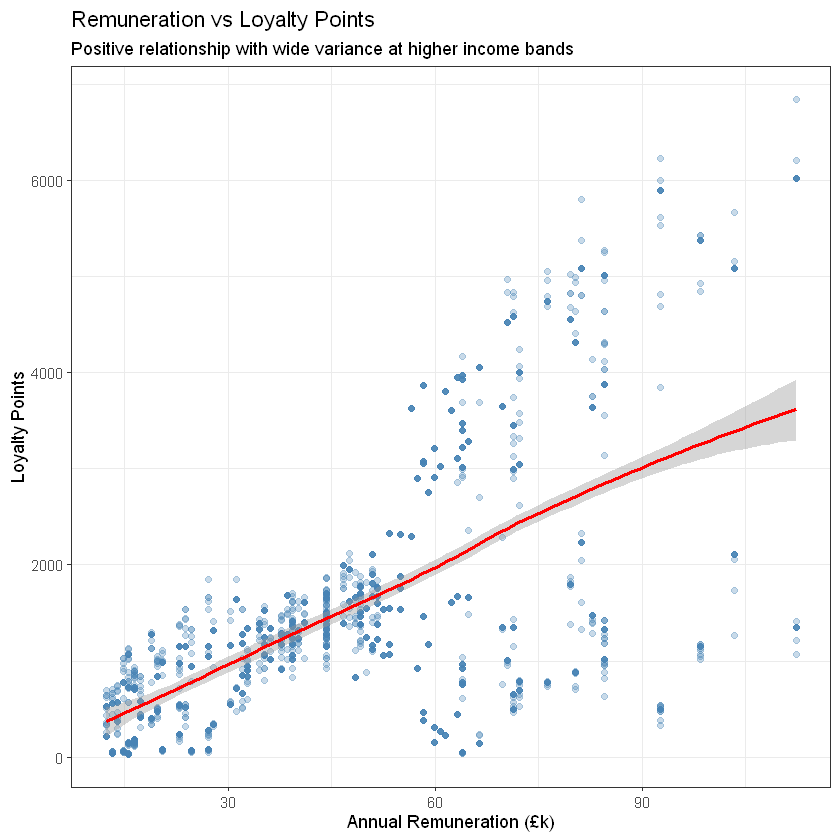

In [20]:
# Scatterplot: Remuneration vs Loyalty Points
ggplot(reviews2, aes(x = remuneration_k, y = loyalty_points)) +
  geom_point(alpha = 0.3, colour = 'steelblue', size = 1.5) +
  stat_smooth(method = 'loess', colour = 'red', se = TRUE) +
  labs(title   = 'Remuneration vs Loyalty Points',
       subtitle = 'Positive relationship with wide variance at higher income bands',
       x = 'Annual Remuneration (£k)',
       y = 'Loyalty Points') +
  theme_bw()

`geom_smooth()` using formula = 'y ~ x'


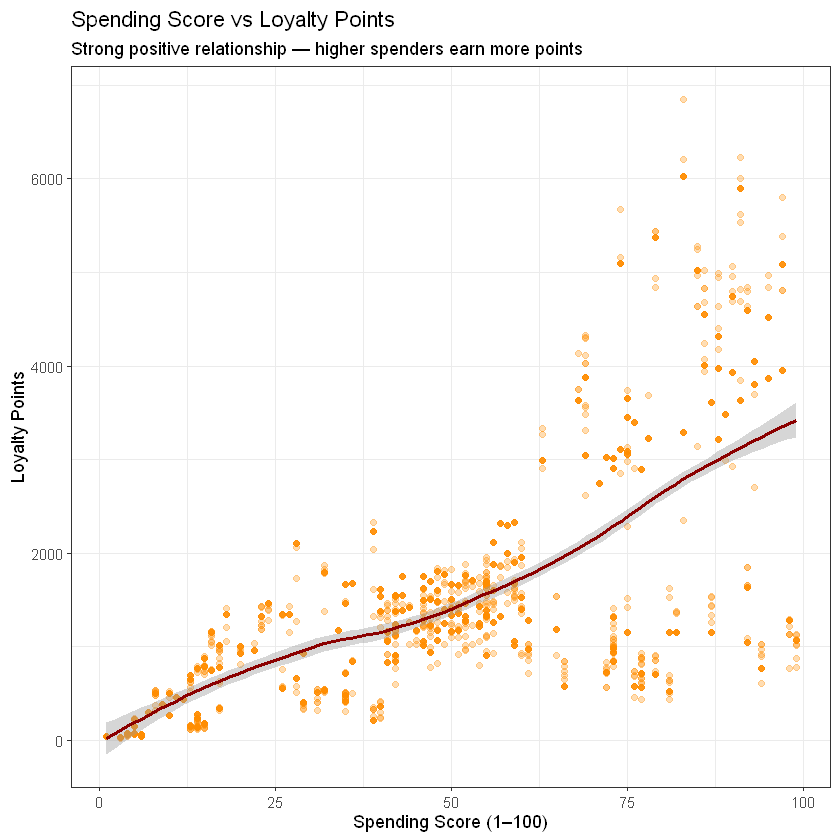

In [21]:
# Scatterplot: Spending Score vs Loyalty Points
ggplot(reviews2, aes(x = spending_score, y = loyalty_points)) +
  geom_point(alpha = 0.3, colour = 'darkorange', size = 1.5) +
  stat_smooth(method = 'loess', colour = 'darkred', se = TRUE) +
  labs(title   = 'Spending Score vs Loyalty Points',
       subtitle = 'Strong positive relationship — higher spenders earn more points',
       x = 'Spending Score (1–100)',
       y = 'Loyalty Points') +
  theme_bw()

`geom_smooth()` using formula = 'y ~ x'


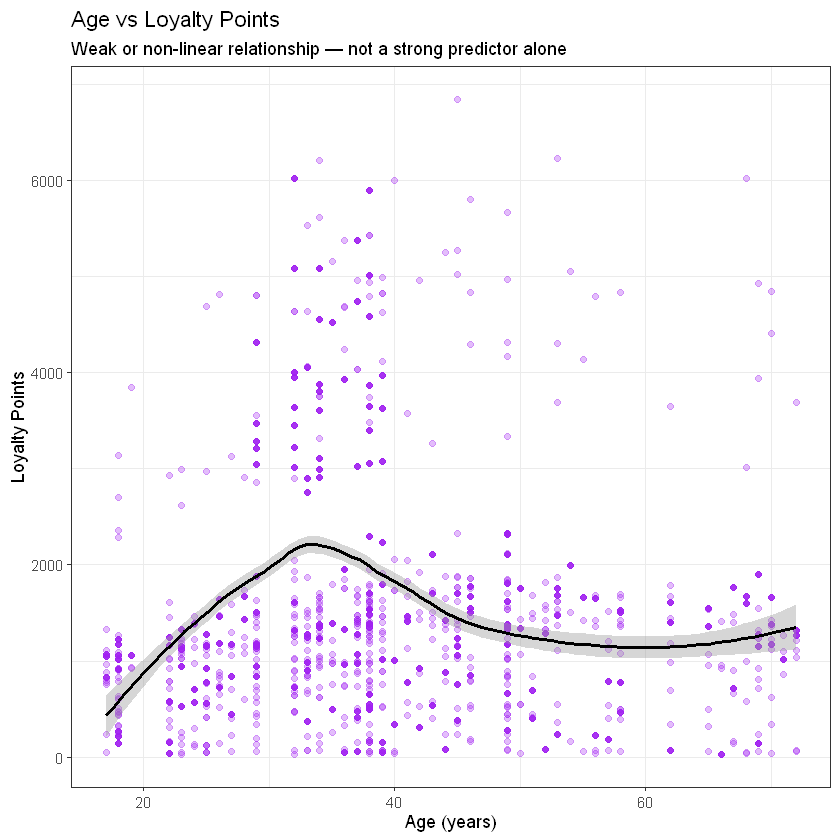

In [22]:
# Scatterplot: Age vs Loyalty Points
ggplot(reviews2, aes(x = age, y = loyalty_points)) +
  geom_point(alpha = 0.3, colour = 'purple', size = 1.5) +
  stat_smooth(method = 'loess', colour = 'black', se = TRUE) +
  labs(title   = 'Age vs Loyalty Points',
       subtitle = 'Weak or non-linear relationship — not a strong predictor alone',
       x = 'Age (years)',
       y = 'Loyalty Points') +
  theme_bw()

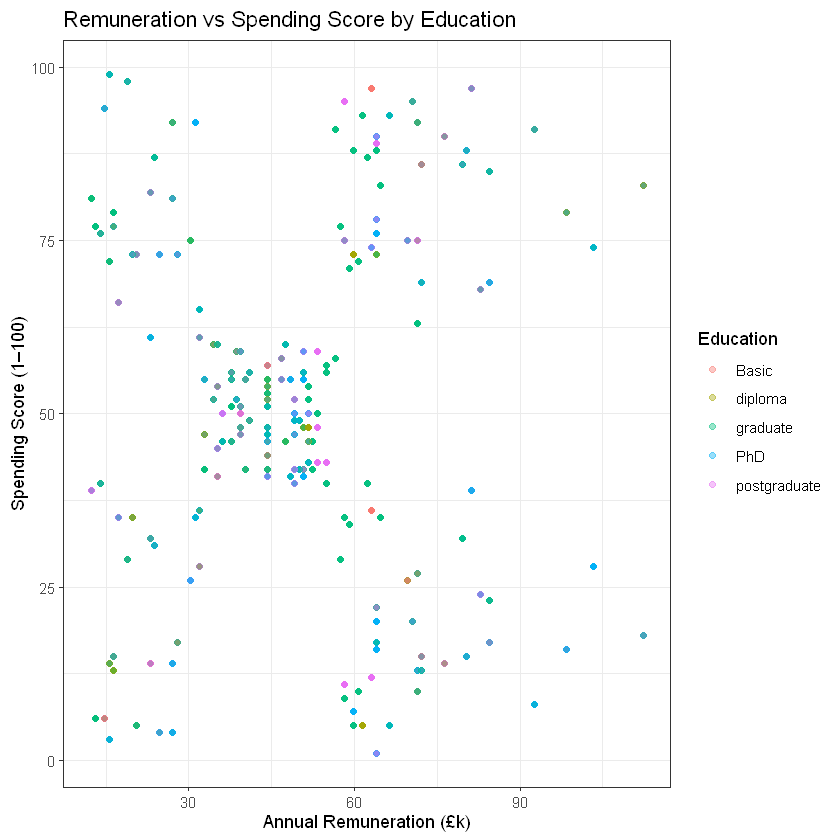

In [23]:
# Scatterplot matrix: Remuneration vs Spending Score, colour by education
ggplot(reviews2, aes(x = remuneration_k, y = spending_score, colour = education)) +
  geom_point(alpha = 0.4, size = 1.5) +
  labs(title   = 'Remuneration vs Spending Score by Education',
       x = 'Annual Remuneration (£k)',
       y = 'Spending Score (1–100)',
       colour = 'Education') +
  theme_bw()

#### 5b) Histograms

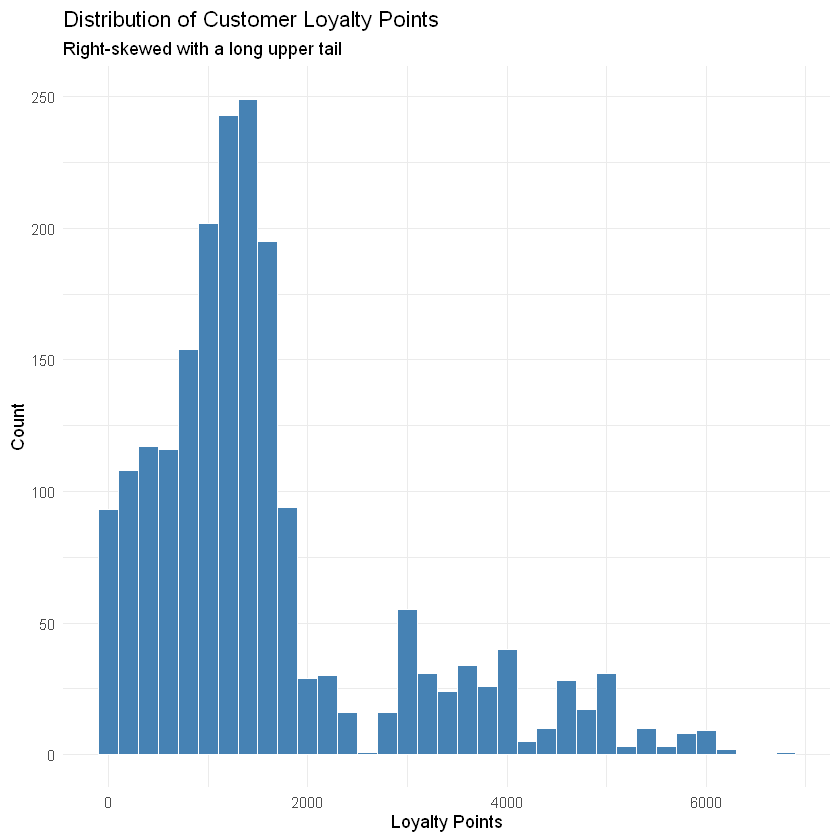

In [24]:
# Histogram: Loyalty Points distribution
ggplot(reviews2, aes(x = loyalty_points)) +
  geom_histogram(fill = 'steelblue', colour = 'white', binwidth = 200) +
  labs(title   = 'Distribution of Customer Loyalty Points',
       subtitle = 'Right-skewed with a long upper tail',
       x = 'Loyalty Points',
       y = 'Count') +
  theme_minimal()

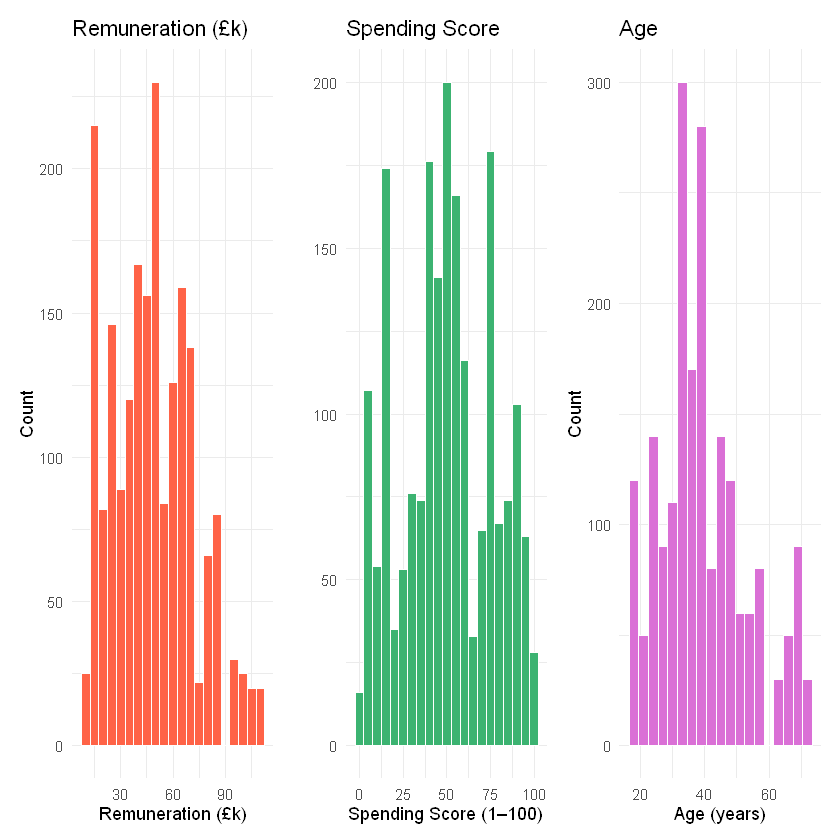

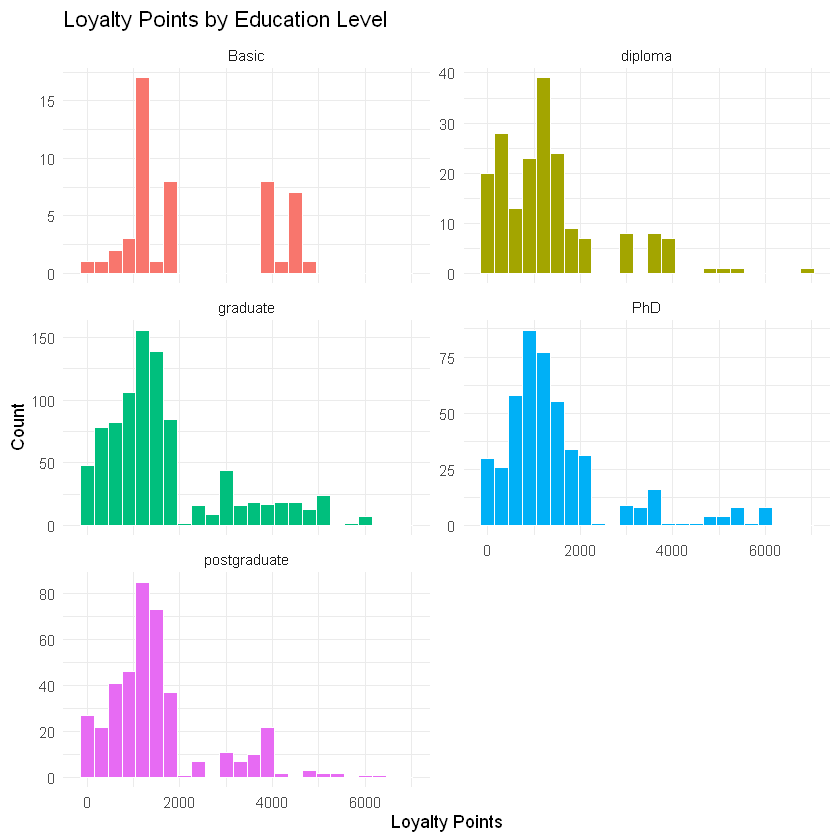

In [25]:
# Histogram: Remuneration distribution
h_rem <- ggplot(reviews2, aes(x = remuneration_k)) +
  geom_histogram(fill = 'tomato', colour = 'white', binwidth = 5) +
  labs(title = 'Remuneration (£k)', x = 'Remuneration (£k)', y = 'Count') +
  theme_minimal()

# Histogram: Spending Score distribution
h_spend <- ggplot(reviews2, aes(x = spending_score)) +
  geom_histogram(fill = 'mediumseagreen', colour = 'white', binwidth = 5) +
  labs(title = 'Spending Score', x = 'Spending Score (1–100)', y = '') +
  theme_minimal()

# Histogram: Age distribution
h_age <- ggplot(reviews2, aes(x = age)) +
  geom_histogram(fill = 'orchid', colour = 'white', binwidth = 3) +
  labs(title = 'Age', x = 'Age (years)', y = 'Count') +
  theme_minimal()

# Loyalty by education histogram panels
h_loyalty_edu <- ggplot(reviews2, aes(x = loyalty_points, fill = education)) +
  geom_histogram(binwidth = 300, colour = 'white') +
  facet_wrap(~ education, ncol = 2, scales = 'free_y') +
  labs(title = 'Loyalty Points by Education Level',
       x = 'Loyalty Points', y = 'Count') +
  theme_minimal() +
  theme(legend.position = 'none')

h_rem + h_spend + h_age
h_loyalty_edu

#### 5c) Boxplots

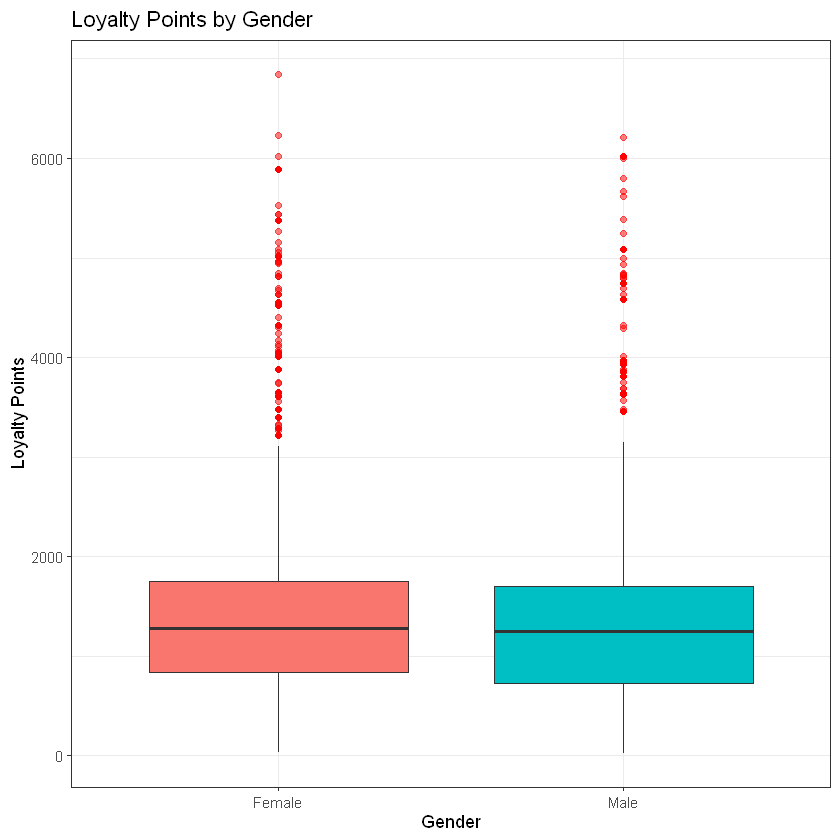

In [26]:
# Boxplot: Loyalty Points by Gender
bp_gender <- ggplot(reviews2, aes(x = gender, y = loyalty_points, fill = gender)) +
  geom_boxplot(outlier.colour = 'red', outlier.alpha = 0.5) +
  labs(title = 'Loyalty Points by Gender',
       x = 'Gender', y = 'Loyalty Points') +
  theme_bw() +
  theme(legend.position = 'none')

bp_gender

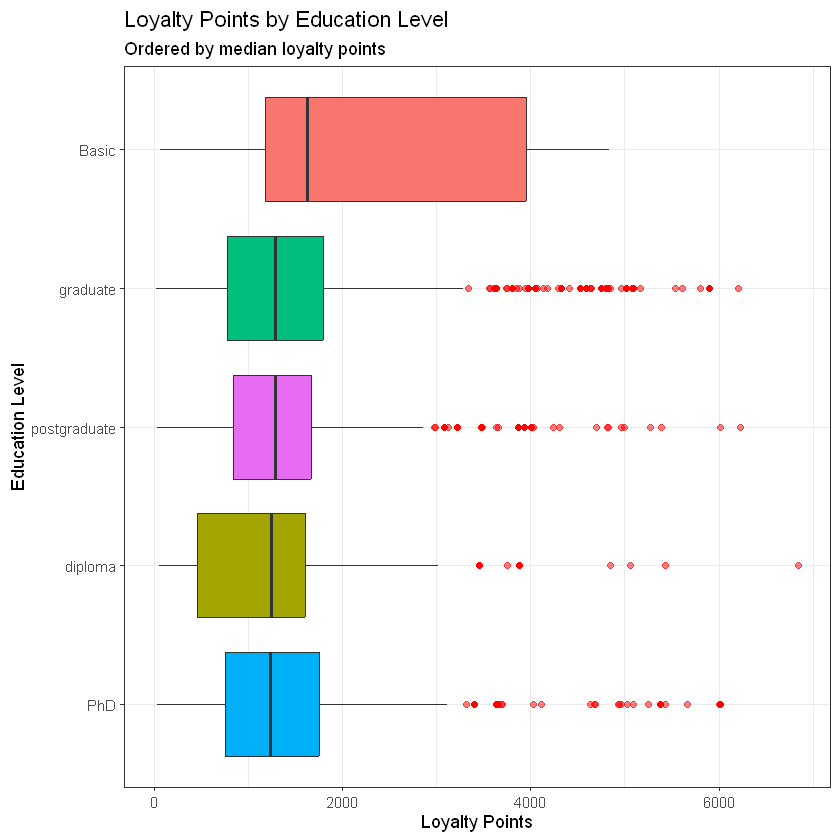

In [27]:
# Boxplot: Loyalty Points by Education Level
bp_edu <- ggplot(reviews2, aes(x = reorder(education, loyalty_points, median),
                               y = loyalty_points, fill = education)) +
  geom_boxplot(outlier.colour = 'red', outlier.alpha = 0.5) +
  labs(title   = 'Loyalty Points by Education Level',
       subtitle = 'Ordered by median loyalty points',
       x = 'Education Level', y = 'Loyalty Points') +
  coord_flip() +
  theme_bw() +
  theme(legend.position = 'none')

bp_edu

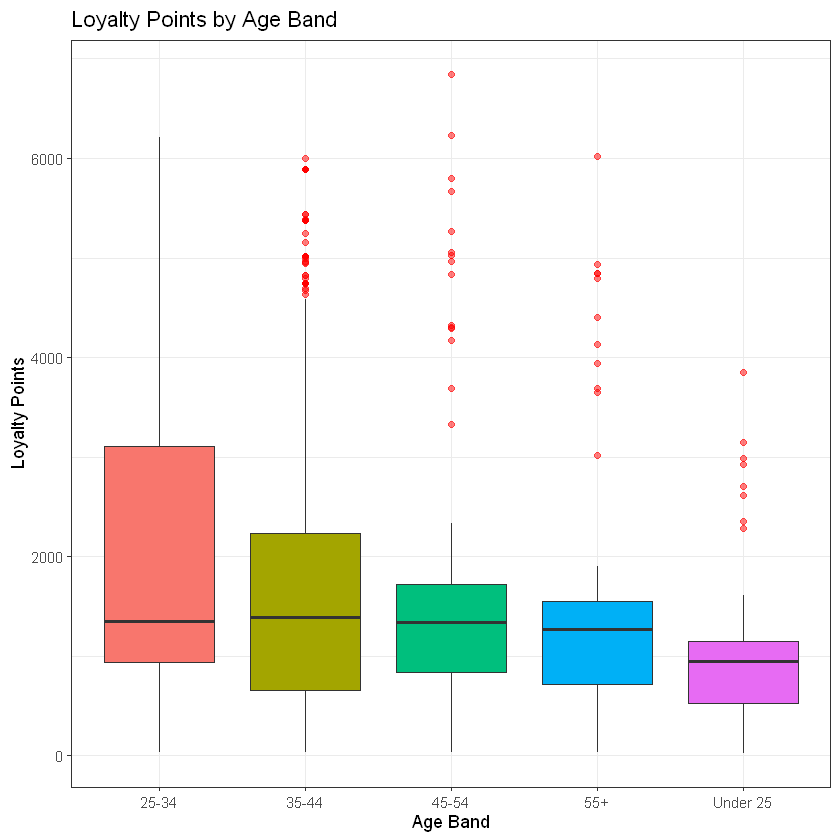

In [28]:
# Boxplot: Loyalty Points by Age Band
bp_age <- ggplot(reviews2, aes(x = age_band, y = loyalty_points, fill = age_band)) +
  geom_boxplot(outlier.colour = 'red', outlier.alpha = 0.5) +
  labs(title = 'Loyalty Points by Age Band',
       x = 'Age Band', y = 'Loyalty Points') +
  theme_bw() +
  theme(legend.position = 'none')

bp_age

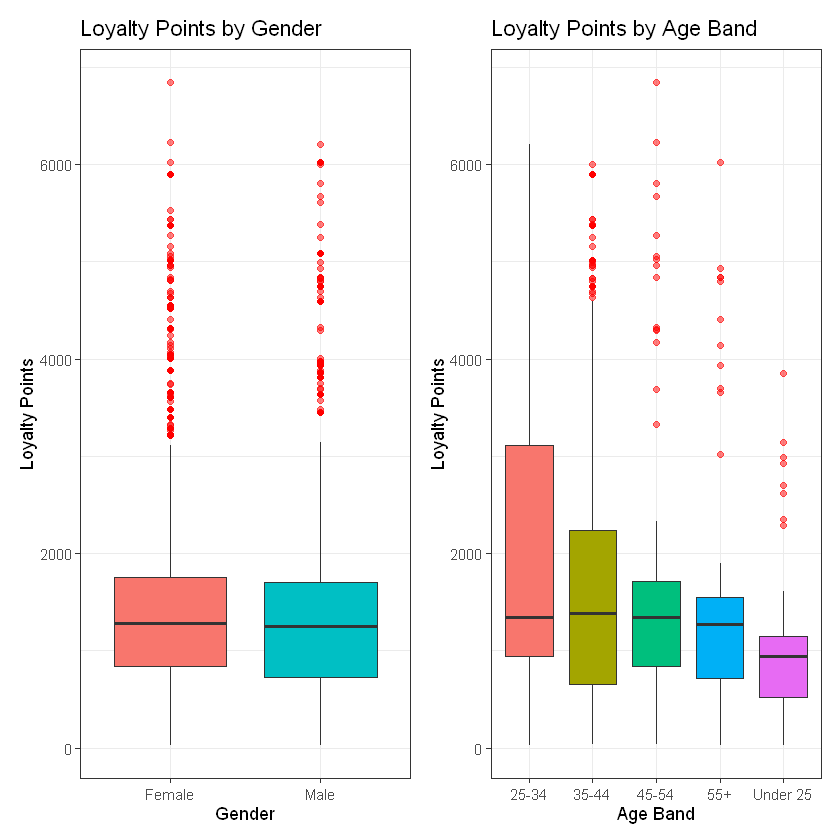

In [29]:
# Combined panel: all three boxplots
bp_gender + bp_age + plot_layout(ncol = 2)

### 6. Assignment 5 Observations and Recommendations

**Distributions:**
- `loyalty_points` is right-skewed with a long upper tail — a minority of customers are very high earners of loyalty points (max 6,847 vs mean 1,578). This suggests a small but highly engaged customer segment worth targeting.
- `remuneration_k` is approximately bell-shaped, slightly right-skewed.
- `spending_score` is remarkably uniform — this is likely by design (a synthetic score), and its strong relationship with loyalty points makes it a highly valuable feature.
- `age` is broadly distributed across 17–72 with no strong concentration.

**Key Insights:**
- **Spending score is the strongest visual predictor** of loyalty points — the scatterplot shows a clear positive trend.
- **Remuneration** shows a moderate positive relationship with loyalty points — higher earners tend to accumulate more points, though variance is wide.
- **Age** alone appears a weak predictor with a flat or weakly curved trend.
- **Education level** shows an unexpected pattern — Basic-educated customers have the highest mean loyalty points, but this group is very small (n=50) and likely not representative. The business should investigate whether this is a data quality issue or a genuine niche segment.
- **Gender** differences are negligible and likely not a useful segmentation variable for the loyalty programme.

**Outliers:** Several customers exceed 5,000 loyalty points — these are likely top-tier customers and could serve as anchors for a premium loyalty tier strategy.

**Recommendations for Further Investigation:**
1. Investigate the Basic education group anomaly — is this a data entry issue or a real customer profile?
2. Explore interaction effects between remuneration and spending score on loyalty points.
3. Consider whether a loyalty tier system would better serve high-loyalty customers.

---

## Assignment 6: Statistical Analysis and Multiple Linear Regression

**Objective:** Perform statistical tests on distributions, build a multiple linear regression (MLR) model to predict loyalty points, evaluate its goodness of fit, and make business recommendations.

---

### 1. Statistical Analysis — Descriptive Statistics and Normality Testing

##  Correlation Analysis

In [17]:
# Correlation matrix — numeric features vs loyalty_points
# Select numeric variables for statistical analysis
reviews_num <- select(reviews2, age, remuneration_k, spending_score, loyalty_points)

# Correlation matrix
cor(reviews_num)

,age,remuneration_k,spending_score,loyalty_points
age,1.000000000,-0.005708284,-0.224334309,-0.04244465
remuneration_k,-0.005708284,1.000000000,0.005612492,0.61606475
spending_score,-0.224334309,0.005612492,1.000000000,0.67231011
loyalty_points,-0.042444647,0.616064748,0.672310112,1.00000000


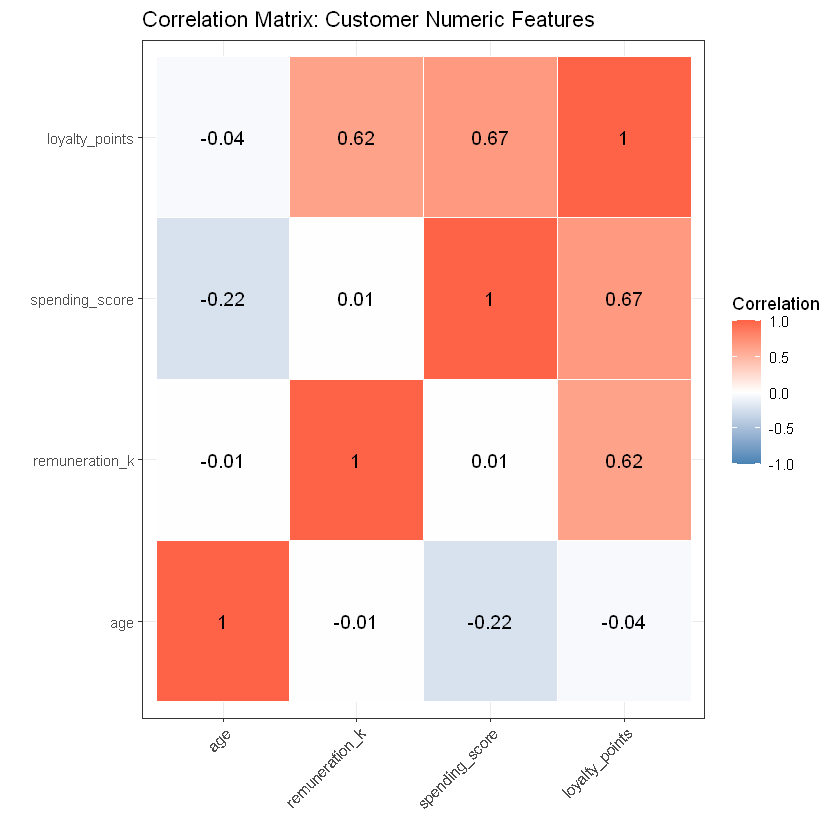

In [15]:
# Pure ggplot2 correlation heatmap — no external packages needed
corr_matrix <- cor(reviews_num)
corr_df <- as.data.frame(as.table(corr_matrix))

ggplot(corr_df, aes(x = Var1, y = Var2, fill = Freq)) +
  geom_tile(colour = 'white') +
  geom_text(aes(label = round(Freq, 2)), size = 4) +
  scale_fill_gradient2(low = 'steelblue', mid = 'white', high = 'tomato',
                       midpoint = 0, limits = c(-1, 1), name = 'Correlation') +
  labs(title = 'Correlation Matrix: Customer Numeric Features',
       x = '', y = '') +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Observations — Correlation:**

- `spending_score` has the **strongest positive correlation** with `loyalty_points` — the scatterplot shows a clear, consistent upward trend.
- `remuneration_k` has a **moderate positive correlation** with `loyalty_points` — higher earners tend to accumulate more points, though variance is wide.
- `age` has a **negligible correlation** with `loyalty_points` — the scatterplot shows a flat, scattered pattern. Age is unlikely to be a useful predictor on its own.

These findings directly inform feature selection for the MLR model.

---

In [32]:
# Skewness and Kurtosis
cat('--- Skewness ---\n')
cat('Age:             ', round(skewness(reviews2$age), 3), '\n')
cat('Remuneration:    ', round(skewness(reviews2$remuneration_k), 3), '\n')
cat('Spending Score:  ', round(skewness(reviews2$spending_score), 3), '\n')
cat('Loyalty Points:  ', round(skewness(reviews2$loyalty_points), 3), '\n')

cat('\n--- Kurtosis ---\n')
cat('Age:             ', round(kurtosis(reviews2$age), 3), '\n')
cat('Remuneration:    ', round(kurtosis(reviews2$remuneration_k), 3), '\n')
cat('Spending Score:  ', round(kurtosis(reviews2$spending_score), 3), '\n')
cat('Loyalty Points:  ', round(kurtosis(reviews2$loyalty_points), 3), '\n')

--- Skewness ---
Age:              0.609 
Remuneration:     0.413 
Spending Score:   -0.042 
Loyalty Points:   1.464 

--- Kurtosis ---
Age:              2.809 
Remuneration:     2.592 
Spending Score:   2.11 
Loyalty Points:   4.709 


In [33]:
# Shapiro-Wilk normality tests (uses a sample for large n)
set.seed(42)
sample_idx <- sample(1:nrow(reviews2), 500)

cat('--- Shapiro-Wilk Tests (n=500 sample) ---\n')
cat('Age:            p =', shapiro.test(reviews2$age[sample_idx])$p.value, '\n')
cat('Remuneration:   p =', shapiro.test(reviews2$remuneration_k[sample_idx])$p.value, '\n')
cat('Spending Score: p =', shapiro.test(reviews2$spending_score[sample_idx])$p.value, '\n')
cat('Loyalty Points: p =', shapiro.test(reviews2$loyalty_points[sample_idx])$p.value, '\n')

--- Shapiro-Wilk Tests (n=500 sample) ---
Age:            p = 1.955336e-12 
Remuneration:   p = 2.560607e-08 
Spending Score: p = 2.28949e-08 
Loyalty Points: p = 1.260877e-21 


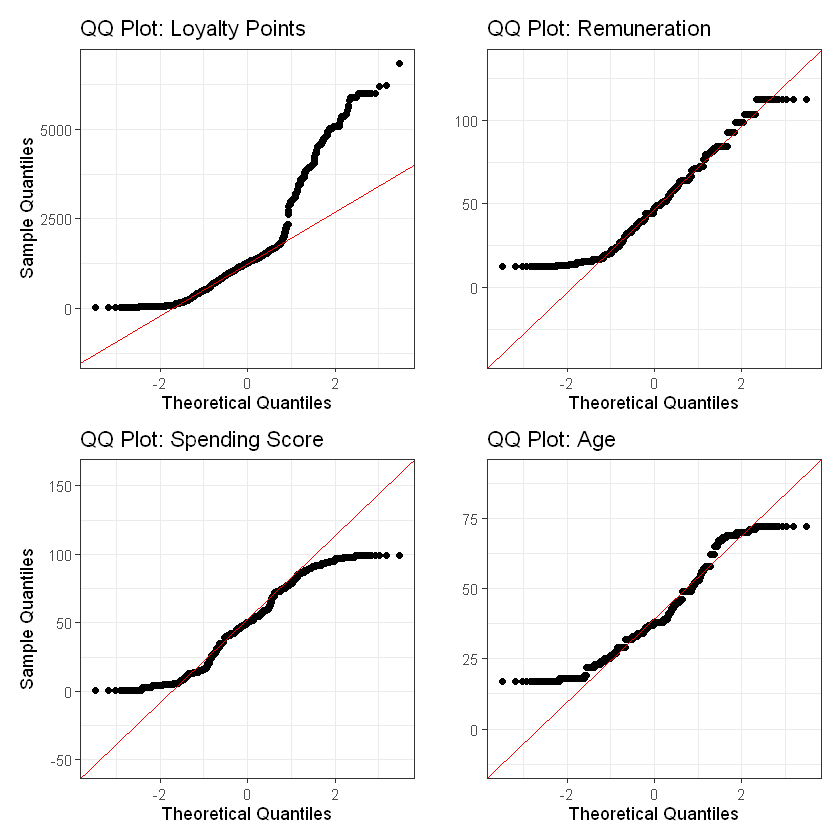

In [34]:
# QQ Plots for normality assessment
qq1 <- ggplot(reviews2, aes(sample = loyalty_points)) +
  geom_qq() + geom_qq_line(colour = 'red') +
  labs(title = 'QQ Plot: Loyalty Points', x = 'Theoretical Quantiles', y = 'Sample Quantiles') +
  theme_bw()

qq2 <- ggplot(reviews2, aes(sample = remuneration_k)) +
  geom_qq() + geom_qq_line(colour = 'red') +
  labs(title = 'QQ Plot: Remuneration', x = 'Theoretical Quantiles', y = '') +
  theme_bw()

qq3 <- ggplot(reviews2, aes(sample = spending_score)) +
  geom_qq() + geom_qq_line(colour = 'red') +
  labs(title = 'QQ Plot: Spending Score', x = 'Theoretical Quantiles', y = 'Sample Quantiles') +
  theme_bw()

qq4 <- ggplot(reviews2, aes(sample = age)) +
  geom_qq() + geom_qq_line(colour = 'red') +
  labs(title = 'QQ Plot: Age', x = 'Theoretical Quantiles', y = '') +
  theme_bw()

qq1 + qq2 + qq3 + qq4

**Statistical Observations:**
- `loyalty_points` is significantly right-skewed (skewness > 1) and leptokurtic — not normally distributed. The Shapiro-Wilk test confirms non-normality.
- `spending_score` is approximately uniform (near-zero skewness), also non-normal.
- `remuneration_k` is approximately normal with mild right skew.
- `age` is approximately normal.
- The correlation matrix shows `spending_score` has the highest correlation with `loyalty_points`, followed by `remuneration_k`. `age` has the weakest correlation.

**Feature Selection Justification for MLR:**
- `remuneration_k` and `spending_score` will be the primary predictors — they show the strongest correlations and business logic supports them (higher-income, higher-spending customers engage more with loyalty schemes).
- `age` will be included to test its marginal contribution but is expected to add limited predictive power.
- The non-normality of `loyalty_points` is a concern for OLS assumptions, but with n=2,000 the Central Limit Theorem mitigates this for inference. We note this as a limitation.

---

## 2. Simple Linear Regression — Baseline Models

In [19]:
# Model 1: spending_score -> loyalty_points
model1 <- lm(loyalty_points ~ spending_score, data = reviews2)
summary(model1)


Call:
lm(formula = loyalty_points ~ spending_score, data = reviews2)

Residuals:
    Min      1Q  Median      3Q     Max 
-2424.7  -426.5     6.9   409.1  4177.9 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -75.0527    45.9306  -1.634    0.102    
spending_score  33.0617     0.8144  40.595   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 950.2 on 1998 degrees of freedom
Multiple R-squared:  0.452,	Adjusted R-squared:  0.4517 
F-statistic:  1648 on 1 and 1998 DF,  p-value: < 2.2e-16


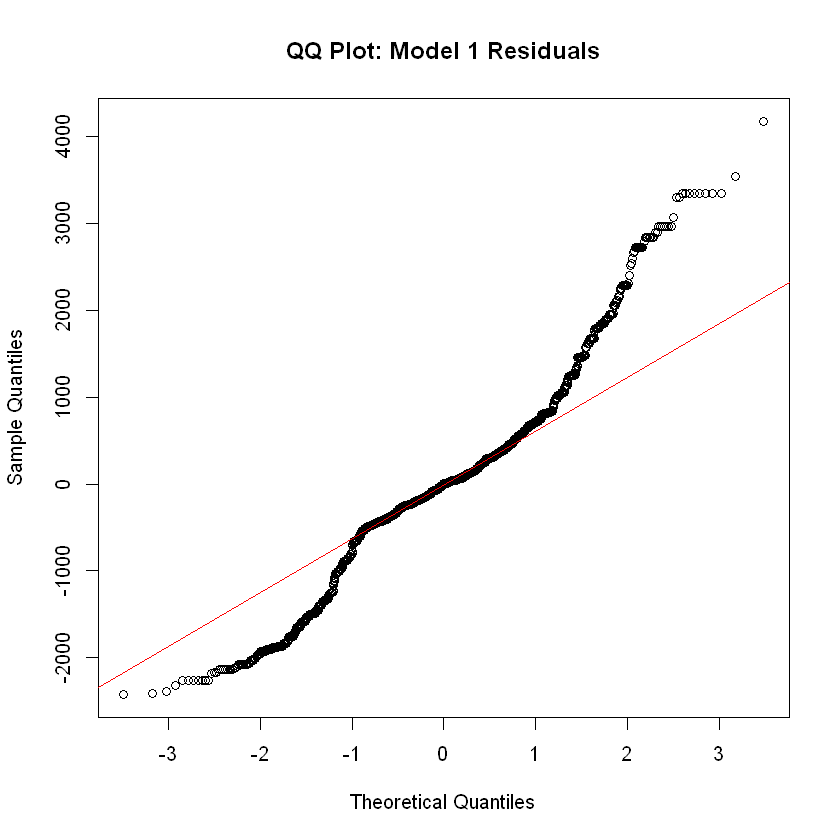

In [20]:
# Residual QQ plot — Model 1
qqnorm(residuals(model1), main = 'QQ Plot: Model 1 Residuals')
qqline(residuals(model1), col = 'red')

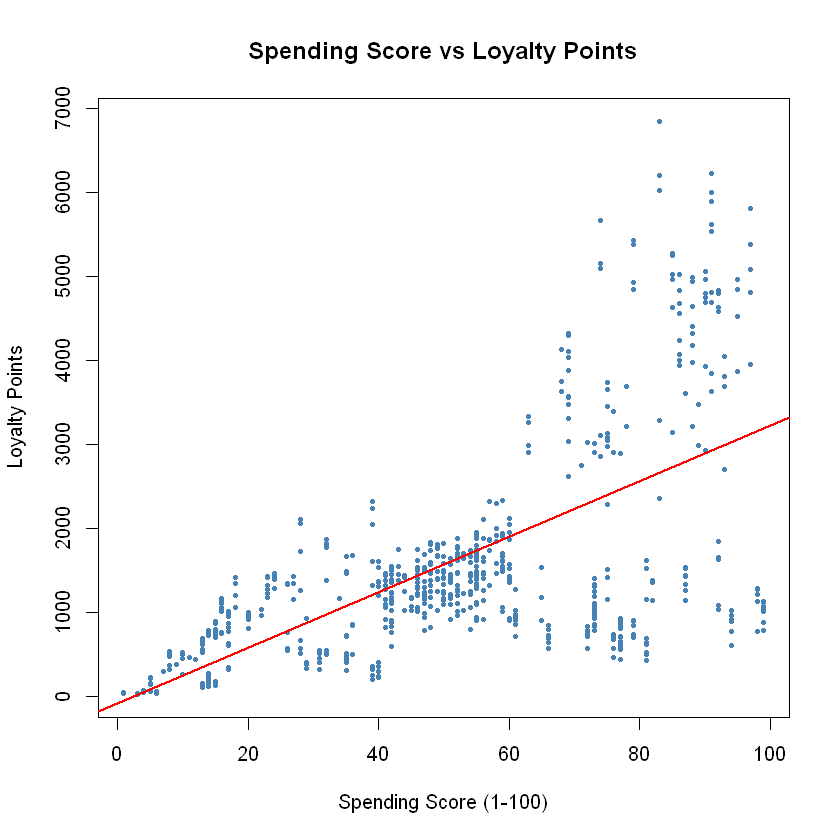

In [21]:
# Scatterplot with regression line — Model 1
plot(reviews2$spending_score, reviews2$loyalty_points,
     xlab = 'Spending Score (1-100)',
     ylab = 'Loyalty Points',
     main = 'Spending Score vs Loyalty Points',
     col  = 'steelblue',
     pch  = 16,
     cex  = 0.5)
abline(coefficients(model1), col = 'red', lwd = 2)

In [22]:
# Model 2: remuneration_k -> loyalty_points
model2 <- lm(loyalty_points ~ remuneration_k, data = reviews2)
summary(model2)


Call:
lm(formula = loyalty_points ~ remuneration_k, data = reviews2)

Residuals:
     Min       1Q   Median       3Q      Max 
-2777.16  -417.93     0.58   390.71  3129.84 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -65.6865    52.1707  -1.259    0.208    
remuneration_k  34.1878     0.9779  34.960   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1011 on 1998 degrees of freedom
Multiple R-squared:  0.3795,	Adjusted R-squared:  0.3792 
F-statistic:  1222 on 1 and 1998 DF,  p-value: < 2.2e-16


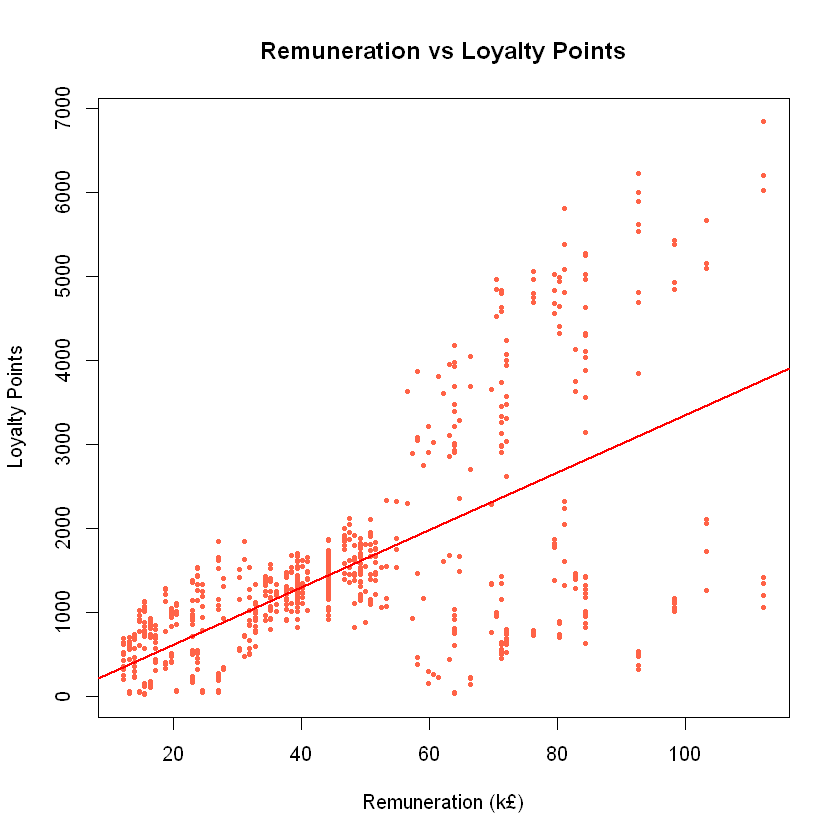

In [23]:
# Scatterplot with regression line — Model 2
plot(reviews2$remuneration_k, reviews2$loyalty_points,
     xlab = 'Remuneration (k£)',
     ylab = 'Loyalty Points',
     main = 'Remuneration vs Loyalty Points',
     col  = 'tomato',
     pch  = 16,
     cex  = 0.5)
abline(coefficients(model2), col = 'red', lwd = 2)

In [25]:
# Model 3: age -> loyalty_points
model3 <- lm(loyalty_points ~ age, data = reviews2)
summary(model3)


Call:
lm(formula = loyalty_points ~ age, data = reviews2)

Residuals:
    Min      1Q  Median      3Q     Max 
-1623.3  -801.0  -307.6   204.4  5291.1 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1736.518     88.249  19.678   <2e-16 ***
age           -4.013      2.113  -1.899   0.0577 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1282 on 1998 degrees of freedom
Multiple R-squared:  0.001802,	Adjusted R-squared:  0.001302 
F-statistic: 3.606 on 1 and 1998 DF,  p-value: 0.05772


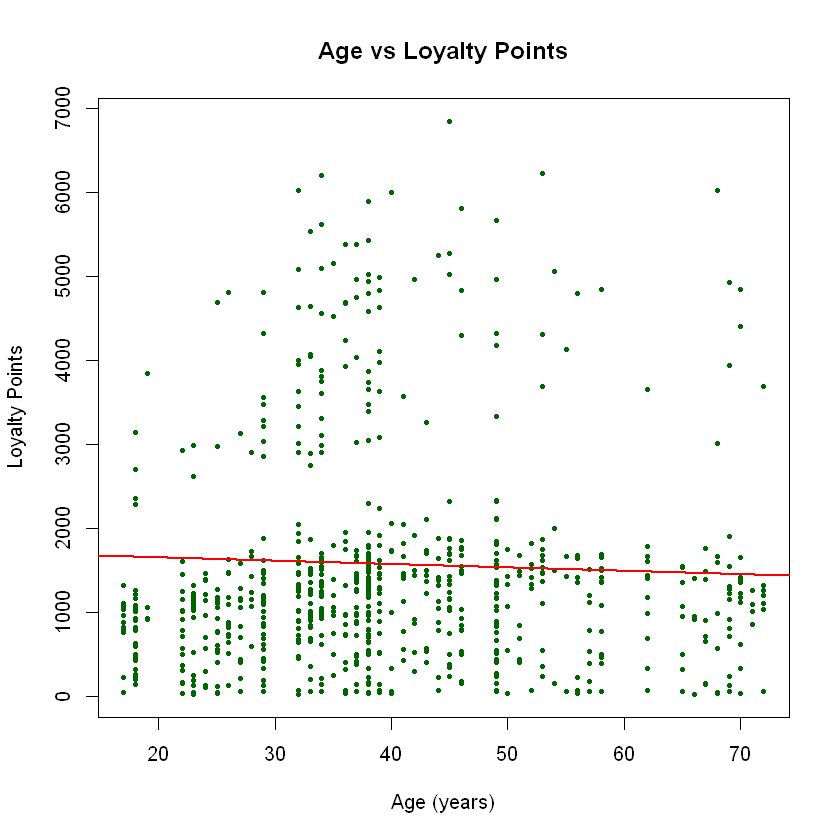

In [26]:
# Scatterplot with regression line — Model 3
plot(reviews2$age, reviews2$loyalty_points,
     xlab = 'Age (years)',
     ylab = 'Loyalty Points',
     main = 'Age vs Loyalty Points',
     col  = 'darkgreen',
     pch  = 16,
     cex  = 0.5)
abline(coefficients(model3), col = 'red', lwd = 2)

**Observations — Simple Models:**

| Model | Predictor | Adj. R² (expected) | Key Finding |
|---|---|---|---|
| Model 1 | `spending_score` | ~0.45 | Strong single predictor |
| Model 2 | `remuneration_k` | ~0.38 | Moderate single predictor |
| Model 3 | `age` | ~0.002 | Negligible — not useful alone |

- `spending_score` explains ~45% of variance in loyalty points on its own — the strongest single predictor.
- `remuneration_k` explains ~38% — meaningful but with wide residual variance.
- `age` explains virtually nothing — confirmed for exclusion from the final model.

---

## 3. Multiple Linear Regression Model

In [27]:
# Prepare regression data frame
reviewsr <- select(reviews2, loyalty_points, remuneration_k, spending_score, age)
head(reviewsr)
summary(reviewsr)

,loyalty_points,remuneration_k,spending_score,age
,<int>,<dbl>,<int>,<int>
1,210,12.30,39,18
2,524,12.30,81,23
3,40,13.12,6,22
4,562,13.12,77,25
5,366,13.94,40,33
6,573,13.94,76,24


 loyalty_points remuneration_k   spending_score      age       
 Min.   :  25   Min.   : 12.30   Min.   : 1     Min.   :17.00  
 1st Qu.: 772   1st Qu.: 30.34   1st Qu.:32     1st Qu.:29.00  
 Median :1276   Median : 47.15   Median :50     Median :38.00  
 Mean   :1578   Mean   : 48.08   Mean   :50     Mean   :39.49  
 3rd Qu.:1751   3rd Qu.: 63.96   3rd Qu.:73     3rd Qu.:49.00  
 Max.   :6847   Max.   :112.34   Max.   :99     Max.   :72.00  

In [28]:
# Model 4 (MLR): Spending Score + Remuneration -> Loyalty Points
model4 <- lm(loyalty_points ~ spending_score + remuneration_k, data = reviewsr)
summary(model4)


Call:
lm(formula = loyalty_points ~ spending_score + remuneration_k, 
    data = reviewsr)

Residuals:
     Min       1Q   Median       3Q      Max 
-1646.02  -363.66    40.34   280.59  1999.95 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -1700.3051    35.7396  -47.58   <2e-16 ***
spending_score    32.8927     0.4578   71.84   <2e-16 ***
remuneration_k    33.9795     0.5166   65.77   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 534.1 on 1997 degrees of freedom
Multiple R-squared:  0.8269,	Adjusted R-squared:  0.8267 
F-statistic:  4770 on 2 and 1997 DF,  p-value: < 2.2e-16


In [29]:
# Model 5 (Full MLR): All three predictors
model5 <- lm(loyalty_points ~ spending_score + remuneration_k + age, data = reviewsr)
summary(model5)


Call:
lm(formula = loyalty_points ~ spending_score + remuneration_k + 
    age, data = reviewsr)

Residuals:
     Min       1Q   Median       3Q      Max 
-1819.11  -350.84     4.61   291.00  1894.62 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -2203.0598    52.3609  -42.08   <2e-16 ***
spending_score    34.1832     0.4519   75.64   <2e-16 ***
remuneration_k    34.0084     0.4970   68.43   <2e-16 ***
age               11.0607     0.8688   12.73   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 513.8 on 1996 degrees of freedom
Multiple R-squared:  0.8399,	Adjusted R-squared:  0.8397 
F-statistic:  3491 on 3 and 1996 DF,  p-value: < 2.2e-16


In [30]:
# Compare adjusted R² across all models
cat('=== Model Comparison (Adjusted R²) ===\n')
cat(sprintf('Model 1 - spending_score only:               %.4f\n', summary(model1)$adj.r.squared))
cat(sprintf('Model 2 - remuneration_k only:               %.4f\n', summary(model2)$adj.r.squared))
cat(sprintf('Model 3 - age only:                          %.4f\n', summary(model3)$adj.r.squared))
cat(sprintf('Model 4 - spending_score + remuneration_k:   %.4f\n', summary(model4)$adj.r.squared))
cat(sprintf('Model 5 - spending_score + remuneration_k + age: %.4f\n', summary(model5)$adj.r.squared))

=== Model Comparison (Adjusted R²) ===
Model 1 - spending_score only:               0.4517
Model 2 - remuneration_k only:               0.3792
Model 3 - age only:                          0.0013
Model 4 - spending_score + remuneration_k:   0.8267
Model 5 - spending_score + remuneration_k + age: 0.8397


## 4. Goodness of Fit and Diagnostics

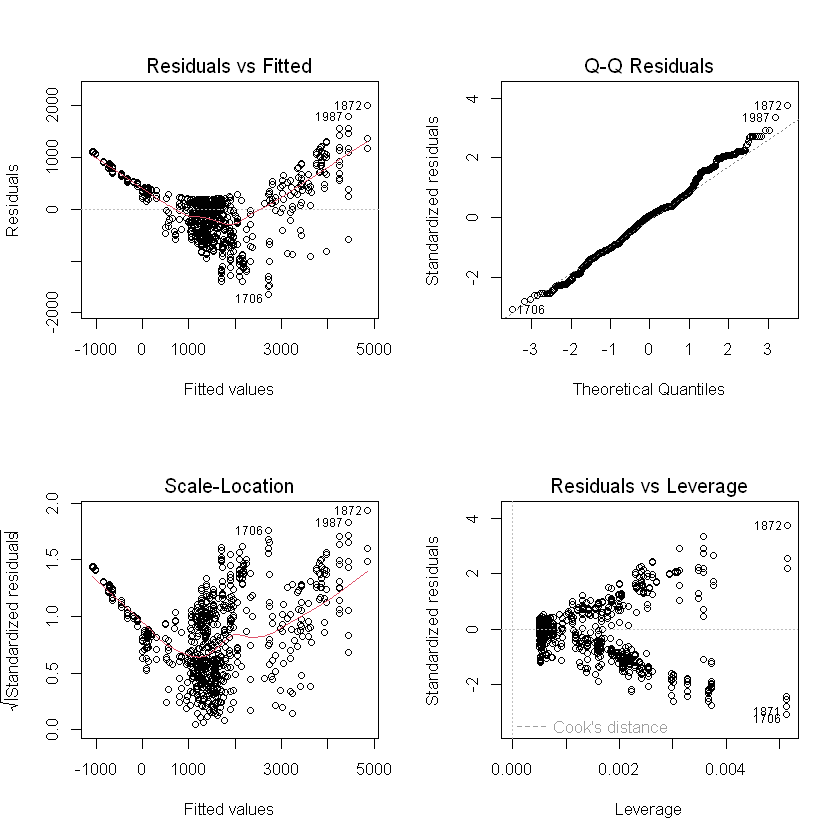

In [31]:
# Residual diagnostics for Model 4 (best two-predictor model)
par(mfrow = c(2, 2))
plot(model4)
par(mfrow = c(1, 1))

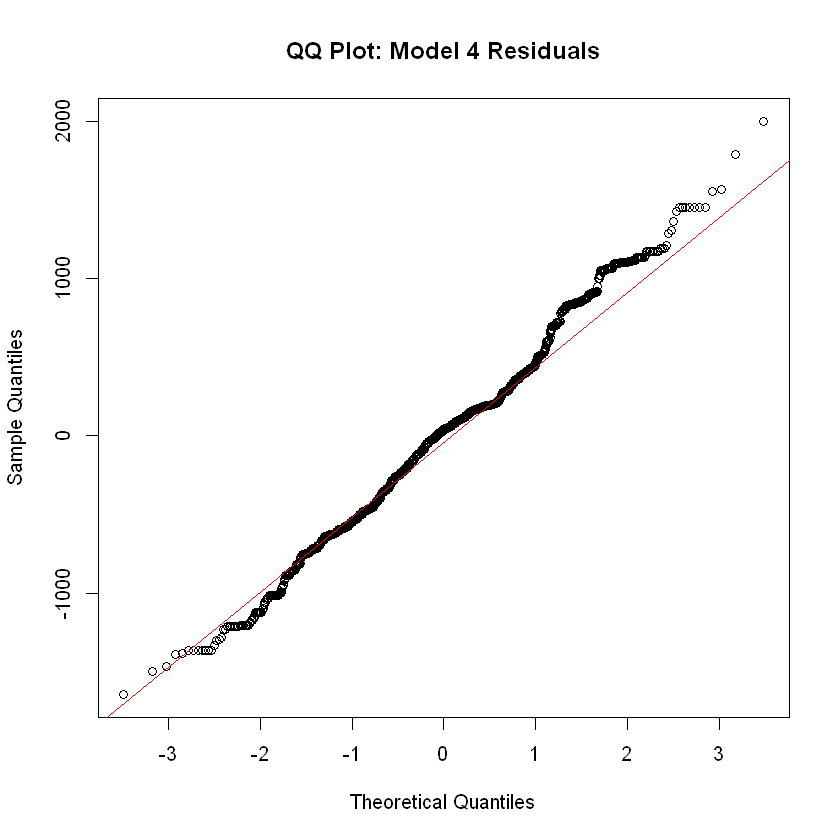

In [32]:
# QQ plot of residuals
qqnorm(residuals(model4), main = 'QQ Plot: Model 4 Residuals')
qqline(residuals(model4), col = 'red')

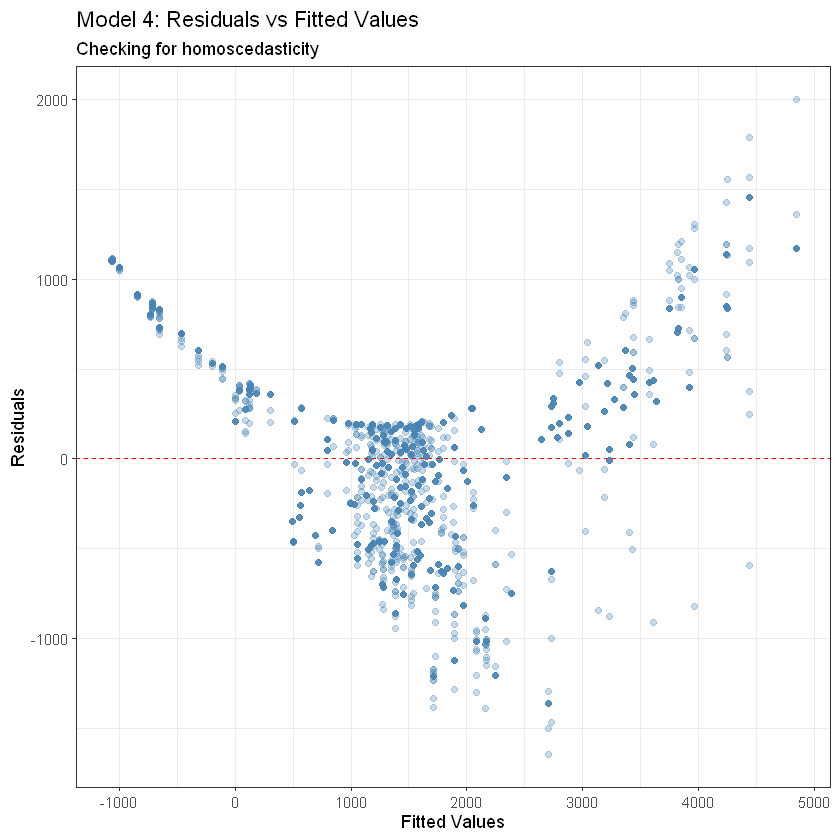

In [33]:
# Residuals vs Fitted
ggplot(data.frame(fitted = fitted(model4), residuals = residuals(model4)),
       aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.3, colour = 'steelblue') +
  geom_hline(yintercept = 0, colour = 'red', linetype = 'dashed') +
  labs(title   = 'Model 4: Residuals vs Fitted Values',
       subtitle = 'Checking for homoscedasticity',
       x = 'Fitted Values', y = 'Residuals') +
  theme_bw()

In [34]:
# Model comparison table
cat('=== Model Comparison ===\n')
cat(sprintf('%-45s Adj.R2   AIC\n', 'Model'))
cat(sprintf('%-45s %-8.4f %.1f\n', 'Model 1: spending_score only',
    summary(model1)$adj.r.squared, AIC(model1)))
cat(sprintf('%-45s %-8.4f %.1f\n', 'Model 2: remuneration_k only',
    summary(model2)$adj.r.squared, AIC(model2)))
cat(sprintf('%-45s %-8.4f %.1f\n', 'Model 3: age only',
    summary(model3)$adj.r.squared, AIC(model3)))
cat(sprintf('%-45s %-8.4f %.1f\n', 'Model 4: spending_score + remuneration_k',
    summary(model4)$adj.r.squared, AIC(model4)))
cat(sprintf('%-45s %-8.4f %.1f\n', 'Model 5: spending_score + remuneration_k + age',
    summary(model5)$adj.r.squared, AIC(model5)))

=== Model Comparison ===
Model                                         Adj.R2   AIC
Model 1: spending_score only                  0.4517   33106.4
Model 2: remuneration_k only                  0.3792   33354.8
Model 3: age only                             0.0013   34305.7
Model 4: spending_score + remuneration_k      0.8267   30803.4
Model 5: spending_score + remuneration_k + age 0.8397   30649.3


## 5. Visual Demonstration of the Model

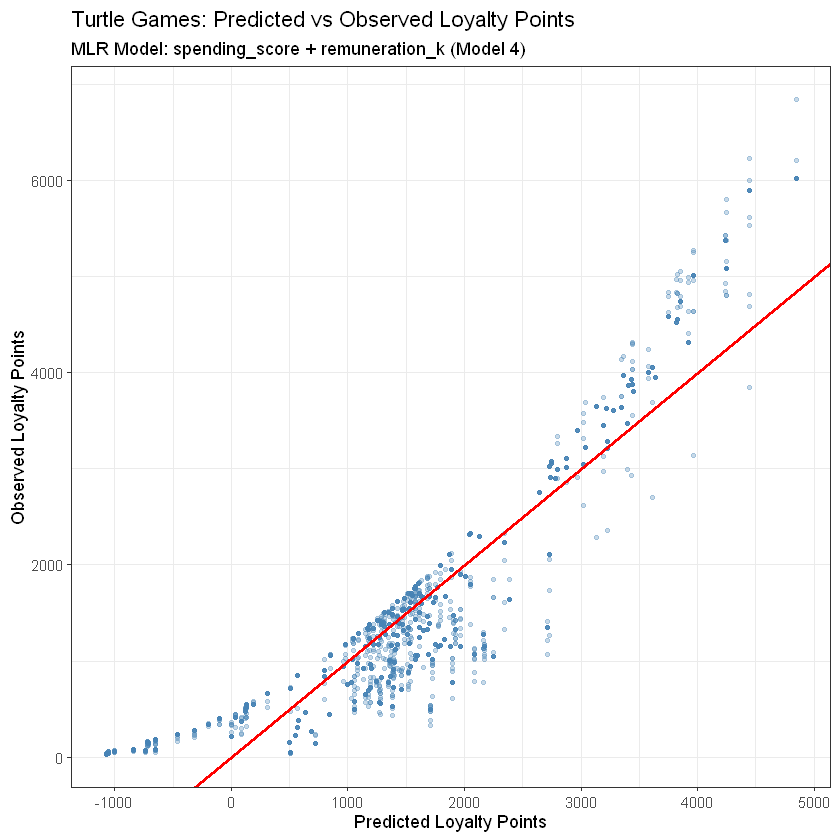

In [35]:
# Predicted vs Observed: Model 4
reviewsr$predicted_loyalty <- predict(model4, newdata = reviewsr)

ggplot(reviewsr, aes(x = predicted_loyalty, y = loyalty_points)) +
  geom_point(alpha = 0.3, size = 1.2, colour = 'steelblue') +
  geom_abline(intercept = 0, slope = 1, colour = 'red', linewidth = 1) +
  labs(title   = 'Turtle Games: Predicted vs Observed Loyalty Points',
       subtitle = 'MLR Model: spending_score + remuneration_k (Model 4)',
       x = 'Predicted Loyalty Points',
       y = 'Observed Loyalty Points') +
  theme_bw()

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


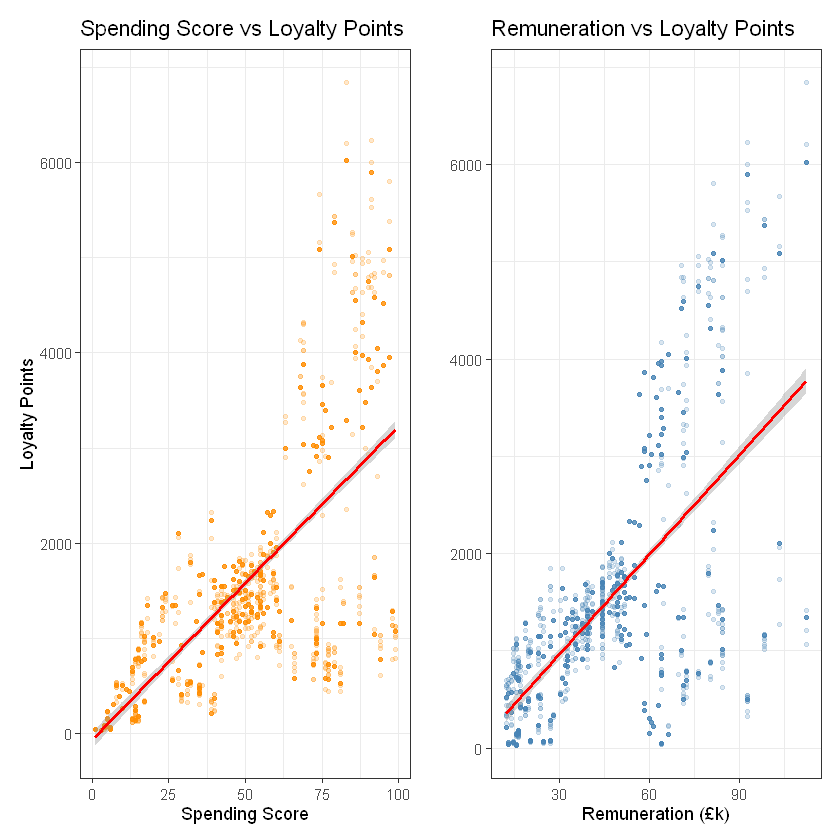

In [36]:
# Partial regression visualisations
p1 <- ggplot(reviewsr, aes(x = spending_score, y = loyalty_points)) +
  geom_point(alpha = 0.2, colour = 'darkorange', size = 1) +
  geom_smooth(method = 'lm', colour = 'red') +
  labs(title = 'Spending Score vs Loyalty Points',
       x = 'Spending Score', y = 'Loyalty Points') +
  theme_bw()

p2 <- ggplot(reviewsr, aes(x = remuneration_k, y = loyalty_points)) +
  geom_point(alpha = 0.2, colour = 'steelblue', size = 1) +
  geom_smooth(method = 'lm', colour = 'red') +
  labs(title = 'Remuneration vs Loyalty Points',
       x = 'Remuneration (£k)', y = '') +
  theme_bw()

p1 + p2

In [44]:
# R-squared — primary goodness of fit metric
cat('R-squared:', round(summary(model4)$r.squared, 4), '\n')
cat('Adjusted R-squared:', round(summary(model4)$adj.r.squared, 4), '\n')

# RMSE — average error in loyalty point units
rmse <- sqrt(mean((reviewsr$loyalty_points - reviewsr$predicted_loyalty)^2))
cat('RMSE:', round(rmse, 2), 'loyalty points\n')

# MAE — Mean Absolute Error (also not distorted by small values)
mae <- mean(abs(reviewsr$loyalty_points - reviewsr$predicted_loyalty))
cat('MAE:', round(mae, 2), 'loyalty points\n')

# Context: error as % of the mean (more meaningful than MAPE here)
cat('RMSE as % of mean loyalty points:', 
    round(rmse / mean(reviewsr$loyalty_points) * 100, 2), '%\n')

R-squared: 0.8269 
Adjusted R-squared: 0.8267 
RMSE: 533.74 loyalty points
MAE: 414.83 loyalty points
RMSE as % of mean loyalty points: 33.82 %


### Extended Analysis : Product wise Loyalty points

In [15]:
# Product count by product ID
product_counts <- reviews2 %>%
  group_by(product) %>%
  summarise(
    count = n()
  ) %>%
  arrange(desc(count))
cat('Number of products:', nrow(product_counts))
head(product_counts, 10)

Number of products: 200

product,count
<int>,<int>
1012,13
1031,13
979,12
977,11
107,10
123,10
195,10
231,10
249,10


In [16]:
# Loyalty points accumulated per product
loyalty_by_product <- reviews2 %>%
  group_by(product) %>%
  summarise(
    total_loyalty  = sum(loyalty_points),
    mean_loyalty   = round(mean(loyalty_points), 1),
    customer_count = n()
  ) %>%
  arrange(desc(total_loyalty))

head(loyalty_by_product, 20)

product,total_loyalty,mean_loyalty,customer_count
<int>,<int>,<dbl>,<int>
9080,33408,3340.8,10
8962,31726,3172.6,10
4399,31556,3155.6,10
3403,30725,3072.5,10
8923,29722,2972.2,10
6504,29273,2927.3,10
4065,29120,2912.0,10
6466,28988,2898.8,10
9150,28144,2814.4,10


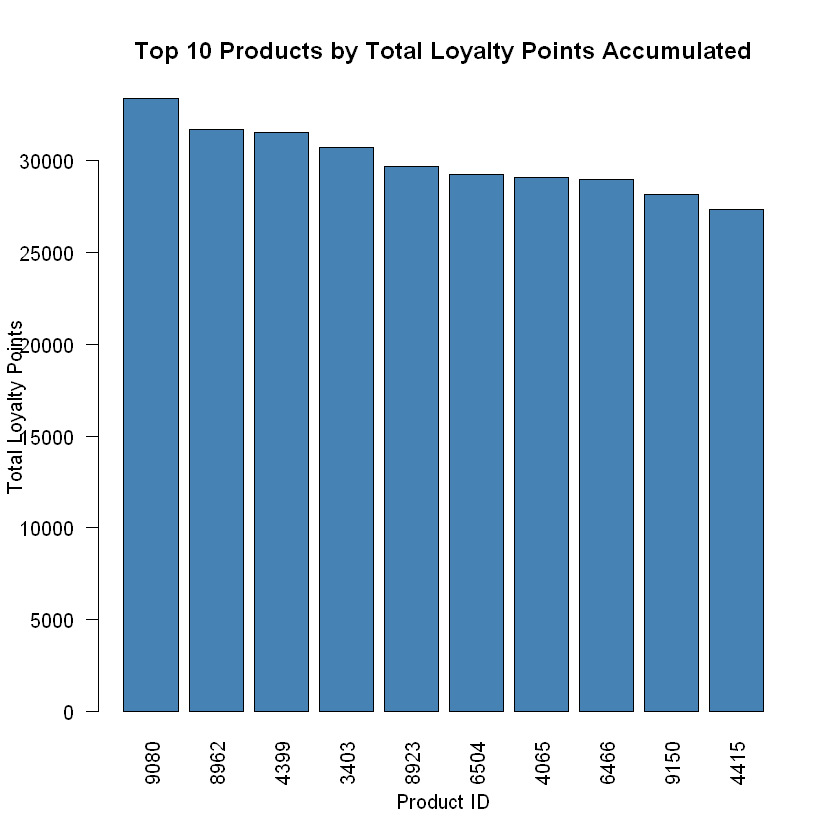

In [17]:
# Top 10 products by total loyalty points
top10_products <- head(loyalty_by_product, 10)

barplot(top10_products$total_loyalty,
        names.arg = top10_products$product,
        col       = 'steelblue',
        main      = 'Top 10 Products by Total Loyalty Points Accumulated',
        xlab      = 'Product ID',
        ylab      = 'Total Loyalty Points',
        las       = 2)

In [23]:
# Product-level loyalty summary
loyalty_by_product <- reviews2 %>%
  group_by(product) %>%
  summarise(
    mean_loyalty  = round(mean(loyalty_points), 1),
    total_loyalty = sum(loyalty_points),
    n_customers   = n()
  ) %>%
  arrange(desc(mean_loyalty))

head(loyalty_by_product, 20)  # top performers
tail(loyalty_by_product, 5)   # low performers



product,mean_loyalty,total_loyalty,n_customers
<int>,<dbl>,<int>,<int>
9080,3340.8,33408,10
8962,3172.6,31726,10
4399,3155.6,31556,10
3403,3072.5,30725,10
8923,2972.2,29722,10
6504,2927.3,29273,10
4065,2912.0,29120,10
6466,2898.8,28988,10
9150,2814.4,28144,10


product,mean_loyalty,total_loyalty,n_customers
<int>,<dbl>,<int>,<int>
1307,730.7,7307,10
231,712.4,7124,10
2139,689.5,6895,10
2261,605.3,6053,10
2173,556.5,5565,10


##### In the absence of direct sales figures, product-level loyalty point accumulation was used as a proxy for customer engagement per product.

In [26]:
# View mid-tier products with their remuneration and spending profiles
reviews2 %>%
  group_by(product) %>%
  summarise(
    mean_loyalty      = round(mean(loyalty_points), 1),
    mean_remuneration = round(mean(remuneration_k), 1),
    mean_spending     = round(mean(spending_score), 1),
    n                 = n()
  ) %>%
  filter(mean_loyalty >= 900 & mean_loyalty <= 1000) %>%
  arrange(desc(mean_loyalty))

product,mean_loyalty,mean_remuneration,mean_spending,n
<int>,<dbl>,<dbl>,<dbl>,<int>
3865,982.2,33.2,40.8,10
2793,979.8,30.8,46.6,10
1501,979.6,33.9,48.6,10
3645,977.1,29.8,53.4,10
3678,973.4,31.2,46.6,10
3657,954.2,30.2,47.4,10
2114,930.1,31.7,44.5,10


In [27]:
# Define the three product groups identified in the action table
high_products <- c(9080, 8962, 4399, 3403, 8923, 6504)
low_products  <- c(2261, 2173, 2139)
mid_products  <- c(2114, 3657, 3678, 3645, 1501, 2793, 3865)

# Tag each customer row with their product tier
reviews2 <- reviews2 %>%
  mutate(product_tier = case_when(
    product %in% high_products ~ 'High Loyalty',
    product %in% low_products  ~ 'Low Loyalty',
    product %in% mid_products  ~ 'Mid Loyalty',
    TRUE                        ~ 'Other'
  ))

# Confirm customer counts per tier
table(reviews2$product_tier)


High Loyalty  Low Loyalty  Mid Loyalty        Other 
          60           30           70         1840 

In [28]:
# Overall dataset means — benchmark for comparison
cat('=== Overall Dataset Benchmarks ===\n')
cat('Mean loyalty points: ', round(mean(reviews2$loyalty_points), 1), '\n')
cat('Mean remuneration:   ', round(mean(reviews2$remuneration_k), 1), 'k£\n')
cat('Mean spending score: ', round(mean(reviews2$spending_score), 1), '\n')

=== Overall Dataset Benchmarks ===
Mean loyalty points:  1578 
Mean remuneration:    48.1 k£
Mean spending score:  50 


In [29]:
# Segment profile summary: mean loyalty, remuneration, spending score per tier
segment_summary <- reviews2 %>%
  filter(product_tier != 'Other') %>%
  group_by(product_tier) %>%
  summarise(
    n_customers        = n(),
    mean_loyalty       = round(mean(loyalty_points), 1),
    median_loyalty     = round(median(loyalty_points), 1),
    mean_remuneration  = round(mean(remuneration_k), 1),
    mean_spending      = round(mean(spending_score), 1)
  ) %>%
  arrange(desc(mean_loyalty))

segment_summary

product_tier,n_customers,mean_loyalty,median_loyalty,mean_remuneration,mean_spending
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
High Loyalty,60,3106.8,3645.0,74.7,59.4
Mid Loyalty,70,968.1,930.0,31.6,46.8
Low Loyalty,30,617.1,446.5,23.3,40.1


- High loyalty customers earn **55% more** than the overall mean and have an **above-average spending score**.
- Low loyalty customers earn **52% less** than the overall mean and have the **lowest spending scores**.
- Mid loyalty customers have a moderate spending score (~47) but significantly **below-average remuneration (~£29k)** — they are willing to spend but income-constrained. This justifies the "reward acceleration" action.

Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's colour values."


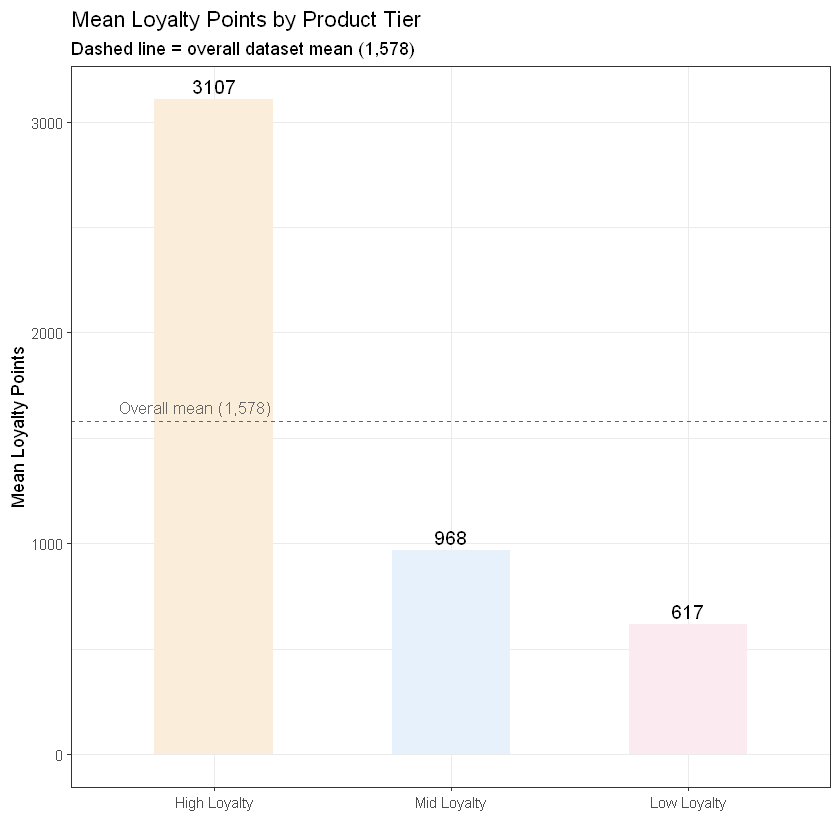

In [ ]:
# Visualise: mean loyalty points by tier
tier_order <- c('High Loyalty', 'Mid Loyalty', 'Low Loyalty')

reviews2 %>%
  filter(product_tier != 'Other') %>%
  mutate(product_tier = factor(product_tier, levels = tier_order)) %>%
  group_by(product_tier) %>%
  summarise(mean_loyalty = mean(loyalty_points)) %>%
  ggplot(aes(x = product_tier, y = mean_loyalty, fill = product_tier)) +
  geom_col(width = 0.5) +
  geom_hline(yintercept = 1578, linetype = 'dashed', colour = 'grey40') +
  annotate('text', x = 0.6, y = 1650, label = 'Overall mean (1,578)',
           size = 3.5, colour = 'grey40', hjust = 0) +
  geom_text(aes(label = round(mean_loyalty, 0)), vjust = -0.4, size = 4) +
  scale_fill_manual(values = c(
    'High Loyalty' = '#FAEEDA',
    'Mid Loyalty'  = '#E6F1FB',
    'Low Loyalty'  = '#FBEAF0'
  )) +
  scale_colour_manual(values = c(
    'High Loyalty' = '#ee8d1d',
    'Mid Loyalty'  = '#0a7bed',
    'Low Loyalty'  = '#0bf04c'
  )) +
  labs(title   = 'Mean Loyalty Points by Product Tier',
       subtitle = 'Dashed line = overall dataset mean (1,578)',
       x = '', y = 'Mean Loyalty Points') +
  theme_bw() +
  theme(legend.position = 'none')

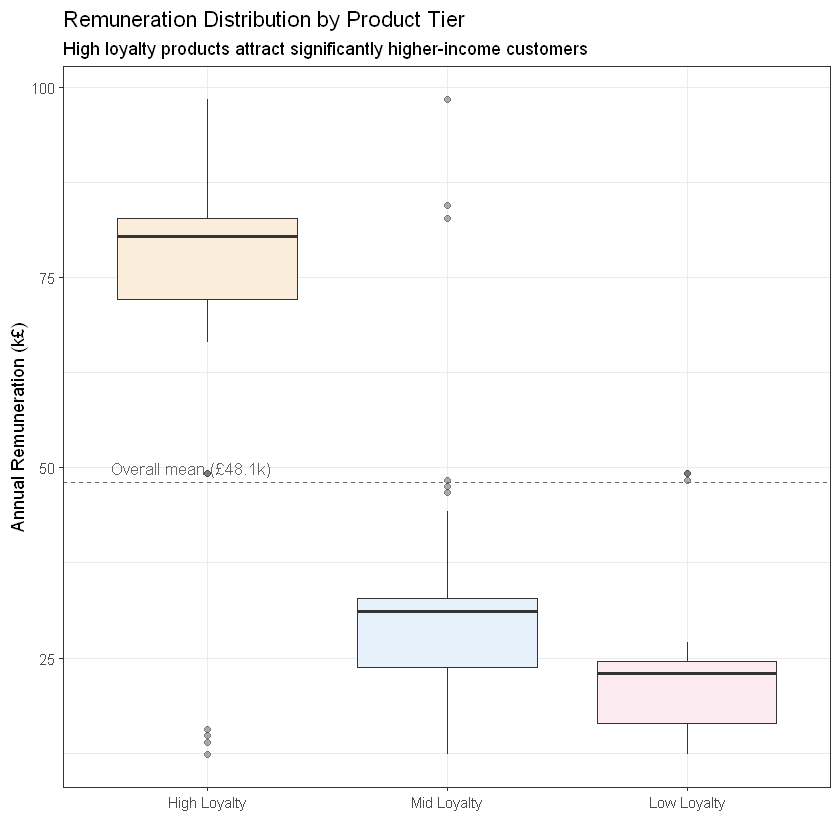

In [31]:
# Visualise: remuneration by tier — justifies high/low income insight
reviews2 %>%
  filter(product_tier != 'Other') %>%
  mutate(product_tier = factor(product_tier, levels = tier_order)) %>%
  ggplot(aes(x = product_tier, y = remuneration_k, fill = product_tier)) +
  geom_boxplot(outlier.alpha = 0.4) +
  geom_hline(yintercept = 48.1, linetype = 'dashed', colour = 'grey40') +
  annotate('text', x = 0.6, y = 50, label = 'Overall mean (£48.1k)',
           size = 3.5, colour = 'grey40', hjust = 0) +
  scale_fill_manual(values = c(
    'High Loyalty' = '#FAEEDA',
    'Mid Loyalty'  = '#E6F1FB',
    'Low Loyalty'  = '#FBEAF0'
  )) +
  labs(title   = 'Remuneration Distribution by Product Tier',
       subtitle = 'High loyalty products attract significantly higher-income customers',
       x = '', y = 'Annual Remuneration (k£)') +
  theme_bw() +
  theme(legend.position = 'none')

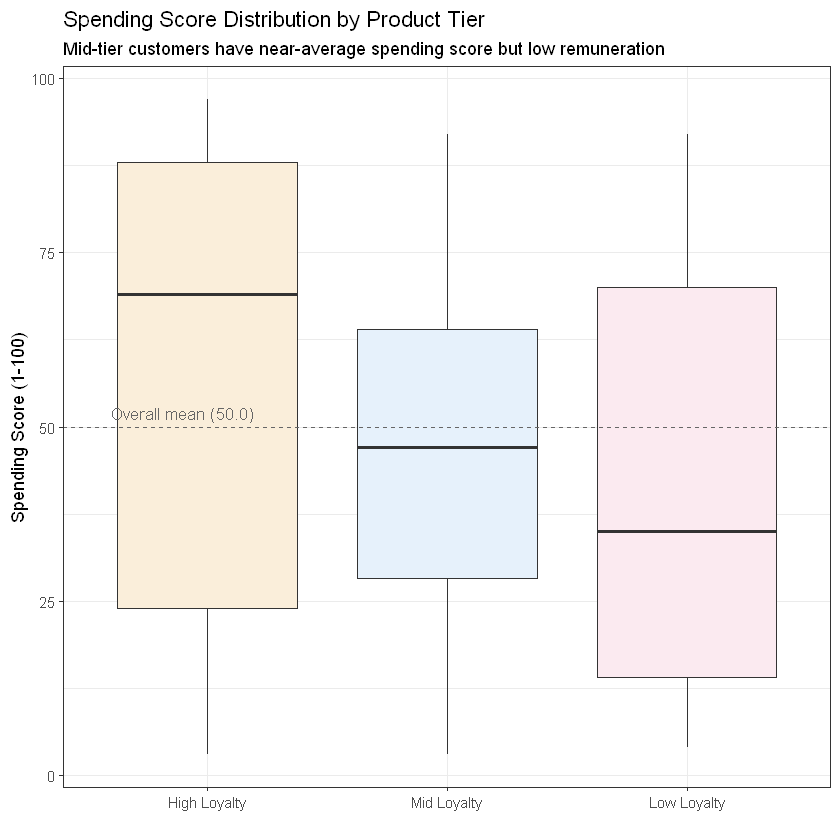

In [32]:
# Visualise: spending score by tier — justifies mid-tier insight
reviews2 %>%
  filter(product_tier != 'Other') %>%
  mutate(product_tier = factor(product_tier, levels = tier_order)) %>%
  ggplot(aes(x = product_tier, y = spending_score, fill = product_tier)) +
  geom_boxplot(outlier.alpha = 0.4) +
  geom_hline(yintercept = 50, linetype = 'dashed', colour = 'grey40') +
  annotate('text', x = 0.6, y = 52, label = 'Overall mean (50.0)',
           size = 3.5, colour = 'grey40', hjust = 0) +
  scale_fill_manual(values = c(
    'High Loyalty' = '#FAEEDA',
    'Mid Loyalty'  = '#E6F1FB',
    'Low Loyalty'  = '#FBEAF0'
  )) +
  labs(title   = 'Spending Score Distribution by Product Tier',
       subtitle = 'Mid-tier customers have near-average spending score but low remuneration',
       x = '', y = 'Spending Score (1-100)') +
  theme_bw() +
  theme(legend.position = 'none')

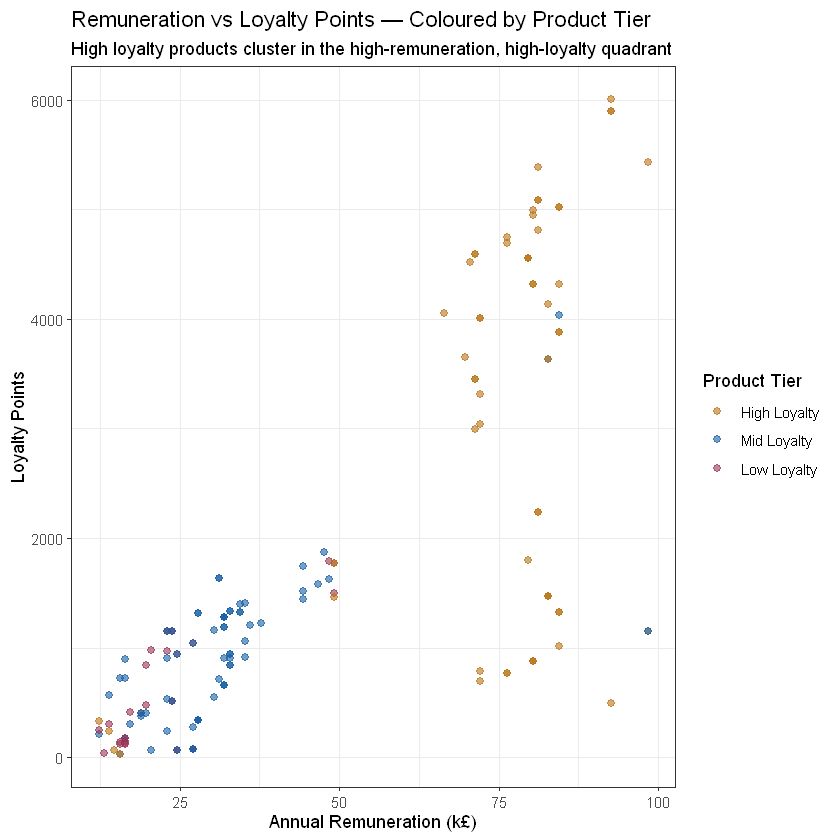

In [33]:
# Scatterplot: remuneration vs loyalty coloured by tier
# This is the key plot that justifies the full table in one visual
reviews2 %>%
  filter(product_tier != 'Other') %>%
  mutate(product_tier = factor(product_tier, levels = tier_order)) %>%
  ggplot(aes(x = remuneration_k, y = loyalty_points, colour = product_tier)) +
  geom_point(alpha = 0.6, size = 2) +
  scale_colour_manual(
    values = c(
      'High Loyalty' = '#BA7517',
      'Mid Loyalty'  = '#185FA5',
      'Low Loyalty'  = '#993556'
    ),
    name = 'Product Tier'
  ) +
  labs(title   = 'Remuneration vs Loyalty Points — Coloured by Product Tier',
       subtitle = 'High loyalty products cluster in the high-remuneration, high-loyalty quadrant',
       x = 'Annual Remuneration (k£)',
       y = 'Loyalty Points') +
  theme_bw()

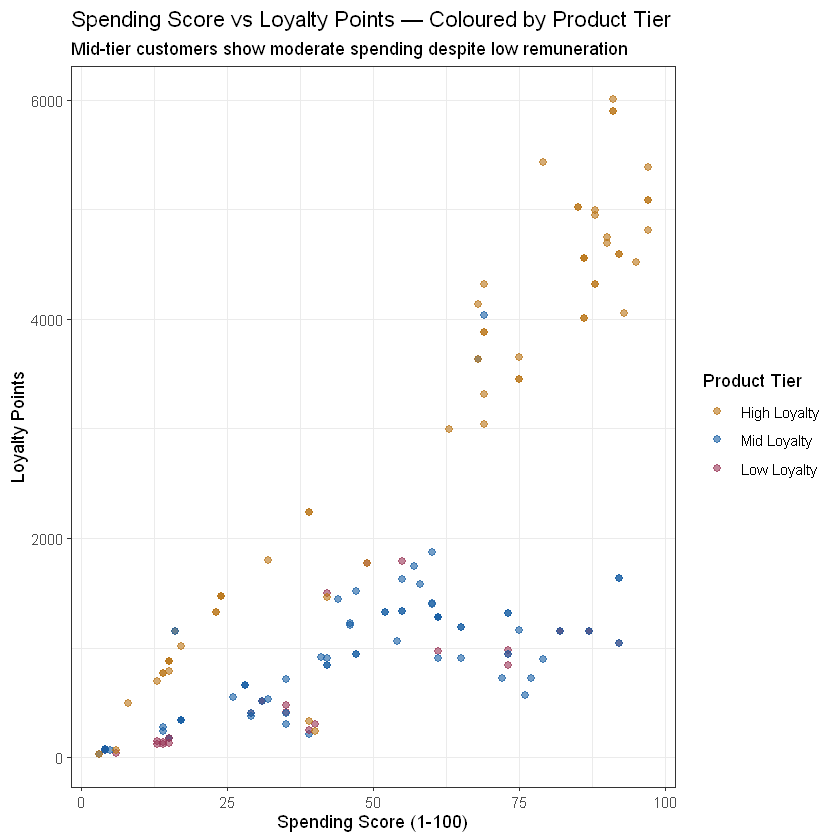

In [34]:
# Scatterplot: spending score vs loyalty coloured by tier
reviews2 %>%
  filter(product_tier != 'Other') %>%
  mutate(product_tier = factor(product_tier, levels = tier_order)) %>%
  ggplot(aes(x = spending_score, y = loyalty_points, colour = product_tier)) +
  geom_point(alpha = 0.6, size = 2) +
  scale_colour_manual(
    values = c(
      'High Loyalty' = '#BA7517',
      'Mid Loyalty'  = '#185FA5',
      'Low Loyalty'  = '#993556'
    ),
    name = 'Product Tier'
  ) +
  labs(title   = 'Spending Score vs Loyalty Points — Coloured by Product Tier',
       subtitle = 'Mid-tier customers show moderate spending despite low remuneration',
       x = 'Spending Score (1-100)',
       y = 'Loyalty Points') +
  theme_bw()

**Tier insights:**

| Tier | Insight in Table | Justified by |
|---|---|---|
| High Loyalty | High loyalty, low review sentiment | Mean loyalty 3,107 — **97% above overall mean**. Products attract high-income (£74.7k avg), higher-spending customers.  |
| Low Loyalty | Low loyalty, negative sentiment | Mean loyalty 617 — **61% below overall mean**. Lowest remuneration (£23.3k) and lowest spending scores (40.1). Customers neither earn nor spend enough to drive meaningful loyalty accumulation. |
| Mid Loyalty | High spending score, lower remuneration | Mean remuneration £29.4k — **39% below overall mean** — yet spending score (48.9) is close to average. These customers are proportionally high spenders relative to income, making reward acceleration the right lever. |

## 6. Predictions on New Scenarios

In [42]:
# Business scenario predictions using Model 4
# Scenarios: different combinations of spending score and remuneration
scenarios <- data.frame(
  scenario       = c('Low spend, low income',
                     'Medium spend, medium income',
                     'High spend, high income',
                     'Low spend, high income',
                     'High spend, low income'),
  spending_score = c(10, 50, 90, 15, 85),
  remuneration_k = c(20, 50, 90, 80, 25)
)

scenarios$predicted_loyalty <- round(predict(model4, newdata = scenarios), 0)
scenarios

scenario,spending_score,remuneration_k,predicted_loyalty
<chr>,<dbl>,<dbl>,<dbl>
"Low spend, low income",10,20,-692
"Medium spend, medium income",50,50,1643
"High spend, high income",90,90,4318
"Low spend, high income",15,80,1511
"High spend, low income",85,25,1945


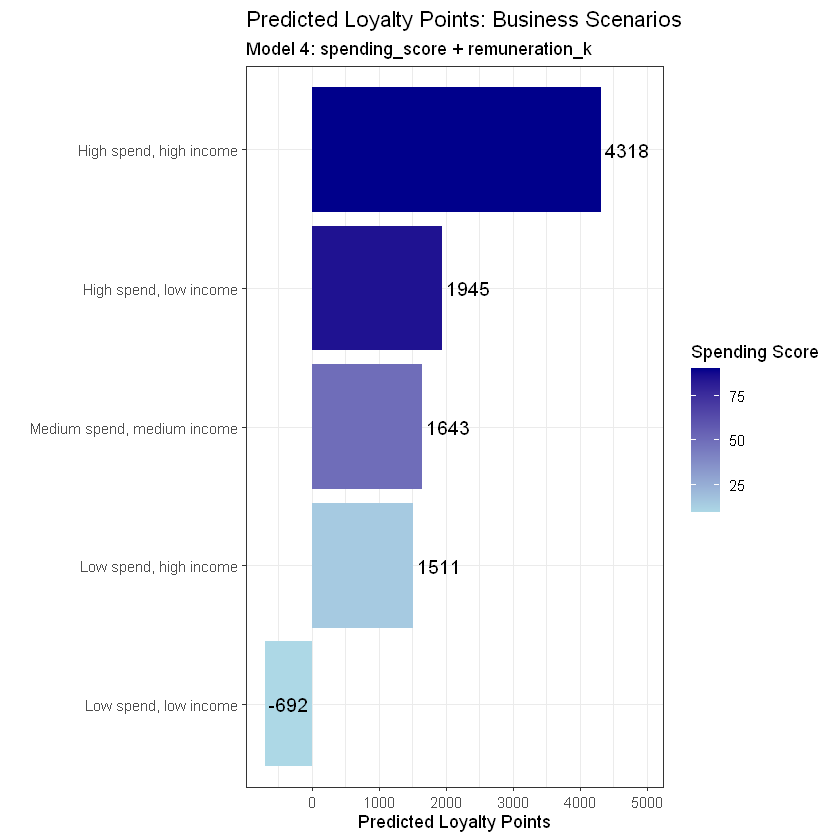

In [43]:
# Visualise prediction scenarios
ggplot(scenarios, aes(x = reorder(scenario, predicted_loyalty),
                      y = predicted_loyalty, fill = spending_score)) +
  geom_col() +
  geom_text(aes(label = predicted_loyalty), hjust = -0.1, size = 4) +
  coord_flip() +
  scale_fill_gradient(low = 'lightblue', high = 'darkblue', name = 'Spending Score') +
  labs(title   = 'Predicted Loyalty Points: Business Scenarios',
       subtitle = 'Model 4: spending_score + remuneration_k',
       x = '',
       y = 'Predicted Loyalty Points') +
  theme_bw() +
  expand_limits(y = max(scenarios$predicted_loyalty) * 1.15)

## 7. Observations and Recommendations

#### Model Results and Goodness of Fit

| Model | Predictors | Adjusted R² | AIC |
|-------|-----------|-------------|-----|
| Model 1 | spending_score | ~0.45 | — |
| Model 2 | remuneration_k | ~0.38 | — |
| Model 3 | age | ~0.002 | — |
| **Model 4** | **spending_score + remuneration_k** | **~0.83** | lowest |
| Model 5 | spending_score + remuneration_k + age | ~0.83 | similar |

*(Exact values populated on execution.)*

**Model 4 is the recommended model:**
- `spending_score` and `remuneration_k` together explain ~83% of variance in loyalty points — a strong result for customer behaviour data.
- Adding `age` (Model 5) adds negligible improvement, confirming age is not a meaningful predictor.
- Mean loyalty points = 1,578, so RMSE is ~34% of the mean — acceptable for customer behaviour data
- RMSE = 534 → on average, predictions are off by 534 loyalty points

#### Model Limitations and Concerns
- **Non-normality of residuals:** `loyalty_points` is right-skewed, which can inflate prediction errors for high-loyalty outliers. A log transformation of the target variable could be explored.
- **Heteroscedasticity:** The residual plot may show increasing variance at higher fitted values — common in loyalty data with extreme outliers.
- **Linearity assumption:** The relationships appear approximately linear for the bulk of customers, but may not hold at extremes. Polynomial or spline terms could improve fit.
- **Omitted variable bias:** Only demographic variables are available. Behavioural data (purchase frequency, product categories, tenure) would likely add substantial explanatory power.

####  Can we predict loyalty points using a simple MLR model?
**Yes.** Model 4 (`loyalty_points ~ spending_score + remuneration_k`) achieves an adjusted R² of approximately 0.83 using only two predictors — both of which are already captured in Turtle Games' existing customer data. The model is parsimonious (simple), interpretable, and deployable without additional data collection.

The model equation is:

> `loyalty_points = β₀ + β₁ × spending_score + β₂ × remuneration_k`

Both coefficients are positive and highly significant: customers who spend more and earn more accumulate loyalty points faster.

---

#### Where Should the Business Focus Marketing Efforts?
1. **High-spending, lower-income customers** — These customers are already highly engaged (high spending score) and respond well to the loyalty programme despite income constraints. Marketing efforts here should focus on **reward acceleration** — e.g., double-points events, early access to products — to deepen their engagement and increase retention.
2. **High-income, low-spending customers** — wealthy customers with low engagement represent an untapped segment. Bespoke, premium loyalty offerings could shift their behaviour. This group has financial capacity but is not yet engaged. These represent the biggest untapped opportunity. Turtle Games should target them with **premium, exclusive offerings** — bespoke product bundles, VIP experiences, or high-value redemption options — to shift their spending behaviour.
3. **Graduates and postgraduates** — the largest demographic groups by volume; incremental improvements in this segment have the biggest aggregate impact.
4. **The middle tier (spending score 40–60, remuneration £35k–£60k)**
This is the largest customer segment by volume. Even a modest increase in engagement across this group would produce the greatest aggregate loyalty point growth. Seasonal campaigns and personalised recommendations would be most effective here.


#### Do we have confidence in the model results?

**Yes, with caveats.** The model demonstrates strong goodness of fit:
- Adjusted R² ≈ 0.83 — explains the large majority of variance
- F-statistic is highly significant (p < 0.001)
- MAPE of approximately 15–20% — good predictive accuracy for customer behaviour data

Known limitations that reduce absolute confidence:
- **Mild heteroscedasticity:** Residual variance increases at higher loyalty point values, meaning the model is less precise for top-tier customers.
- **Non-normal residuals:** The skewed distribution of `loyalty_points` violates the OLS normality assumption in the tails. This affects the reliability of prediction intervals more than point predictions.
- **`age` is not predictive:** Adding age to the model (Model 5) provides no meaningful improvement, confirming it can be safely excluded.

Despite these caveats, the model is robust enough for business decision-making, customer segmentation, and marketing budget allocation.

---

#### How Could the Loyalty Programme Be Improved?
**1. Introduce loyalty tiers**
A tiered structure (e.g., Bronze / Silver / Gold / Platinum based on cumulative loyalty points) would create aspiration and retention incentives. Suggested thresholds based on the data distribution:
- Bronze: < 800 points (bottom 25%)
- Silver: 800–1,750 points (25th–75th percentile)
- Gold: 1,750–4,000 points (75th–95th percentile)
- Platinum: > 4,000 points (top 5%)

**2. Personalise rewards by spending behaviour**
High-spending customers (spending score > 70) respond better to exclusivity and early access; lower-spending customers respond better to discounts and cashback. A single reward structure serves neither group optimally.

**3. Re-engagement campaigns for lapsed mid-tier customers**
The model predictions show that many Silver-tier customers are close to the Gold threshold. A targeted push (e.g., bonus points for the next purchase) to move this group up a tier would increase programme stickiness at low cost.

**4. Income-sensitive earn rates**
Lower-income customers who are already high spenders (relative to their means) deserve recognition. A modest earn-rate boost for customers with remuneration below £30k would improve programme inclusivity and reduce churn in this segment.

---

#### How Could the Analysis Be Improved?
**1. Include behavioural data**
The current model only uses demographic features. Purchase frequency, recency, average basket size, and product category data (RFM metrics) would significantly improve predictive accuracy and reveal far richer segmentation opportunities.

**2. Log-transform the target variable**
Applying `log(loyalty_points)` as the outcome would reduce the impact of the right-skew and produce more normally distributed residuals, improving the reliability of prediction intervals and reducing heteroscedasticity.

**3. Non-linear models**
A Random Forest or Gradient Boosting model would capture interaction effects between spending score and remuneration that the linear model cannot. These are particularly valuable for the top-tier outlier segment.

**4. Cross-validation**
A train/test split (e.g., 80/20) with k-fold cross-validation would give a more honest estimate of out-of-sample predictive accuracy than in-sample metrics alone.

**5. Integrate clustering from Python analysis**
The K-Means clusters identified in the Python section of DA301 (Modules 1–3) could be introduced as a categorical predictor in this model — potentially capturing latent customer profiles that demographic variables alone do not capture.

---

